## Временные ряды. Часть 2.

Разные статистические модели прогнозирования тесно связаны друг с другом: в целях улучшения результата более простые подходы расширялись и становились основой для более сложных. В итоге в статистике появилось несколько методов прогнозирования, отличающихся между собой деталями

### СКОЛЬЗЯЩЕЕ СРЕДНЕЕ

Помимо простого экспоненциального сглаживания, есть также простое сглаживание, или скользящее среднее.

> **Экспоненциальное сглаживание** — это метод прогнозирования временных рядов, который используется для сглаживания данных и выявления трендов.

Для получения элементарного случая **скользящего среднего** проще всего взять среднее арифметическое двух последних наблюдений. Мы получим новый временной ряд, каждый член которого — среднее арифметическое двух соседних значений исходного ряда:

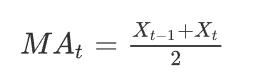

Чуть более продвинутый способ — усреднить сразу несколько наблюдений. Это так называемое **простое скользящее среднее** (Simple Moving Average, SMA):

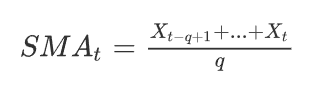

Таким образом, в скользящем среднем мы суммируем несколько последовательных точек временного ряда и делим эту сумму на количество самих точек, то есть считаем математическое усреднение за определённый период.

Количество точек для суммирования определяется размером окна (q). Чем больше размер, тем больше данные сглаживаются.

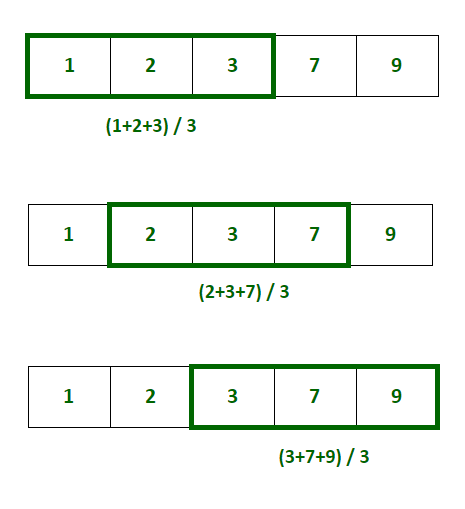

Для сглаживания мы будем использовать встроенный метод `pandas.Series.rolling()` — он принимает на вход параметр `window` и ожидает после себя агрегирующую функцию для сглаживания (обычно используется среднее). Из преимуществ этого метода можно отметить простоту реализации и интерпретации, из недостатков — чувствительность.

Посмотрим на некоторый временной ряд и результаты применения сглаживания к нему:

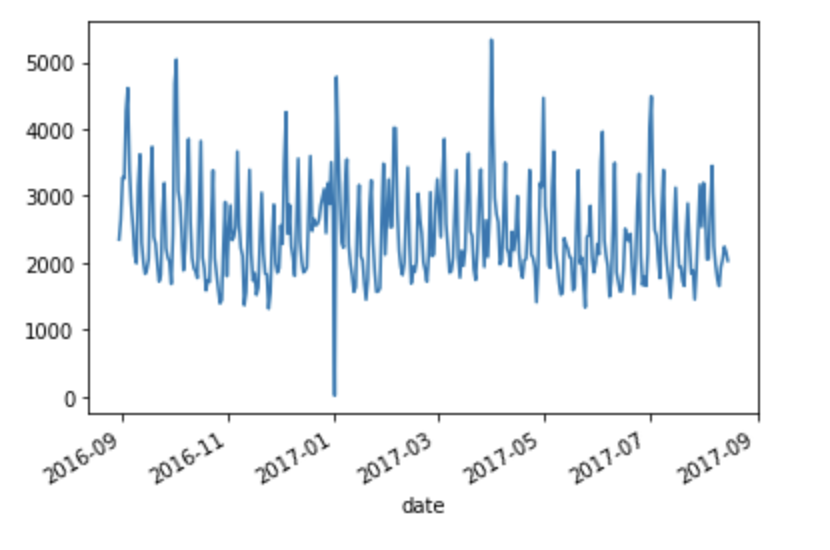

* Скользящее среднее с узким окном (размер окна — два дня) неэффективно борется с выбросами.

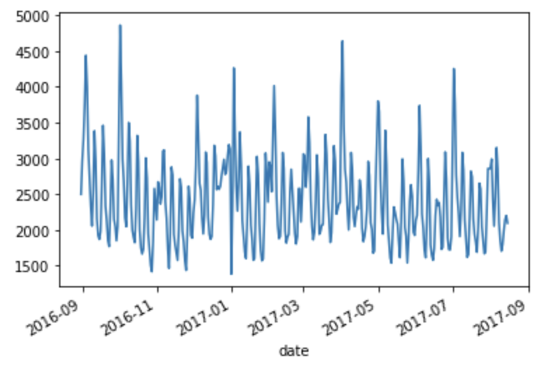

* Скользящее среднее с широким окном (размер окна — 30 дней) может привести к потере информации, сгладив полезную информацию.

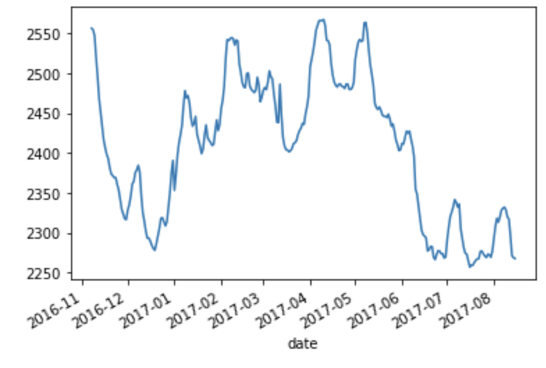

На графике ниже с окном размера 15 есть прослеживающийся период и изменение амплитуды с течением времени.

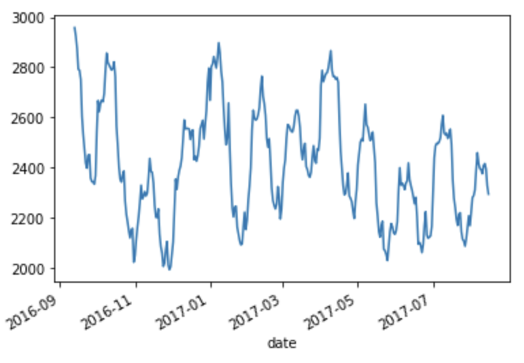

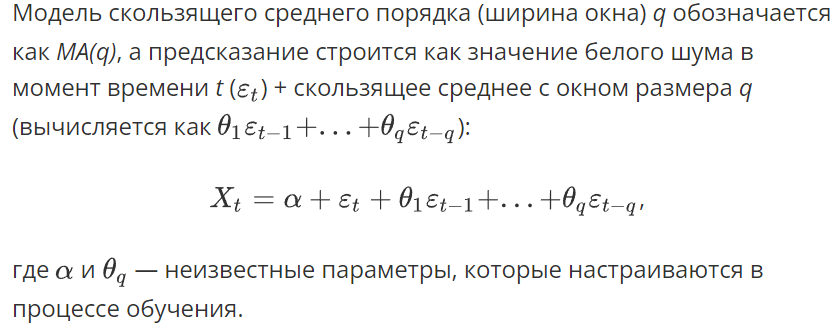

Скользящее среднее редко используется как самостоятельная модель, но иногда помогает избавить ряд от выбросов и лишнего шума, чтобы упростить визуальный анализ.

### ARMA и ARIMA

Что получится, если объединить некоторые из изученных нами методов? Уже есть предположения, что такое ARMA?

Если вы внимательно следили за ходом событий, то смогли догадаться, что **ARMA** — это авторегрессионное скользящее среднее, или модель авторегрессии-скользящего среднего. В ней p **авторегрессионных слагаемых** и q **слагаемых скользящего среднего шумовой компоненты**:

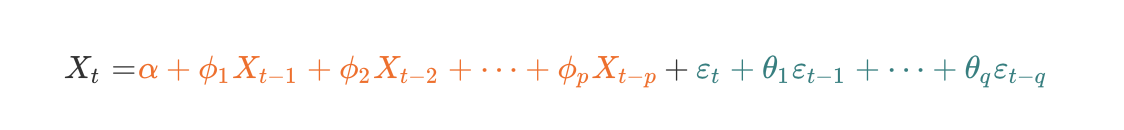

Таким образом ARMA объединяет преимущества двух ранее изученных методов и имеет два параметра:

* p — параметр авторегрессионной модел (AR(p));
* q — параметр скользящего среднего (MA(q)).

Параметр p определяется по графику частичной автокорреляции.

Параметр q для скользящего среднего определяют так же, но по коррелограмме (графику автокорреляции).

**ARIMA** расшифровывается как Autoregressive Integrated Moving Average и включает в себя ещё один параметр (d), который означает, что дифференцирование временного ряда порядка d приводит ряд к стационарности и будет подчиняться модели ARMA.

**d** — это порядок дифференцирования, который приводит нестационарный ряд к стационарности. Это значит, что даже если наш ряд нестационарный, мы можем сделать его стационарным путём взятия разностей (так иногда называют дифференцирование). Запомнив получившееся количество дифференцирований, можно смело применять к нему ARIMA.

И *ARMA*, и *ARIMA* реализованы на Python в классе ARIMA из `statsmodels`. Данному классу необходимо передать в качестве параметров временной ряд и порядок `order (ARIMA(dta, order=(2, 0, 0)))`. Для параметра `order` нужно указать p, d и q (именно в таком порядке), причём для получения ARMA необходимо указать `d=0`.

Резюмируем:

* Если ряд стационарный, используем ARMA.

* Если ряд нестационарный (имеет тренд), с помощью дифференцирования определяем порядок d и используем ARIMA.

Теперь мы можем проверять временные ряды из задач на стационарность и вне зависимости от результата применять к ним одну из статистических моделей.

### SARIMA

Модель *ARIMA* отлично учитывает и тренд (благодаря скользящему среднему), и зависимость от предыдущих значений (благодаря авторегрессии), но в ней не хватает учёта сезонности. В таком случае можно добавить к ARIMA учёт сезонности, и тогда мы получим следующую модель — сезонную ARIMA, или **SARIMA (Seasonal ARIMA)**.

Эта модель очень похожа на ARIMA, за исключением того, что в ней есть дополнительный набор компонентов авторегрессии и скользящего среднего.

SARIMA позволяет различать данные по сезонной частоте, а также по их несезонным отличиям. Нахождение лучших для модели параметров можно упростить с помощью средств автоматического поиска, таких как `auto_arima` из `pmdarima`.

### SARIMAX и ARIMAX

Вы уже могли заметить, что изученные нами статистические модели совершают предсказания, основываясь только на данных самого временного ряда. Но что если месяц или день недели тоже имеет значение? Или, например, на курс рубля, помимо даты и предыдущих значений, также влияют курсы других валют?

Последней статистической моделью, с которой мы познакомимся, будет **SARIMAX**. Её отличие от предыдущей версии заключается в том, что, помимо данных временного ряда, она учитывает экзогенные переменные. Таким образом мы сможем учитывать не только зависимости внутри данных, но и внешние факторы.

> **Экзогенные переменные** - переменные, которые влияют на значение зависимой переменной, но не зависят от нее. Иными словами, экзогенные переменные не зависят от временного ряда, а значит, мы можем контролировать их значения при анализе или прогнозировании временных рядов.

Для запуска моделей SARIMA и SARIMAX на Python нужно воспользоваться классом `SARIMAX`. Если вы хотите использовать SARIMA, необходимо задать два обязательных параметра — `order` и `seasonal_order`.

`order` — это порядок для модели (ARIMA(p, d, q)). В `seasonal_order` необходимо передать ещё четыре параметра:

* P — сезонный авторегрессионный порядок;
* D — порядок дифференцирования сезонного ряда;
* Q — порядок сезонной скользящей средней;
* m — размер сезонного периода.

Если размер сезонного периода m можно определить по сезонной компоненте, то остальные параметры удобнее определять автоперебором.

Для учёта экзогенных переменных необходимо передать в класс SARIMAX параметр `exog=x`. В x должны находиться другие временные ряды, например курс доллара (x), который может влиять на курс рубля (y), или пометка, является ли каждая из дат праздничным днём.

Обратите внимание, что также существует модель **ARIMAX**. Уже есть предположения, когда использовать эту модель? В отличие от SARIMAX, ARIMAX не учитывает сезонную составляющую, но имеет все преимущества ARIMA и учитывает экзогенные переменные.

### Как сравнивать эти модели?

Одним из распространённых способов является сравнение качества моделей по **критерию Акаике (AIC)**. Этот информационный критерий вознаграждает модель за качество приближения обученного временного ряда к фактическому, а также «штрафует» её за использование излишнего количества параметров. Принято считать, что модель с наименьшим значением критерия AIC является наилучшей.

Для оценки модели критерием AIC необязательно пользоваться дополнительными методами. Этот критерий, как и другая информация, отображается после обучения модели при вызове встроенного метода `fit_model.summary()`.

### Как выбрать подходящую модель?

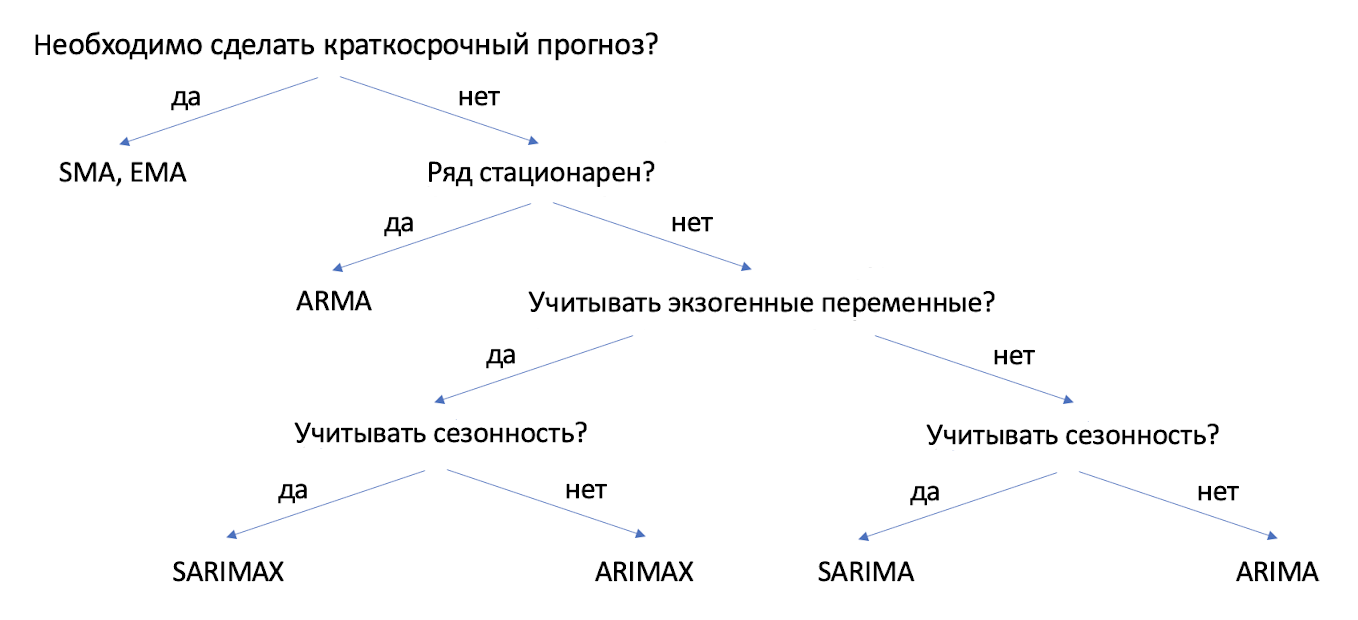

Оценка качества модели информационными критериями продемонстрирована в этой статье - https://www.projectpro.io/article/how-to-build-arima-model-in-python/544

## Практика

**Предсказание финансовых индексов** — актуальная задача, решением которой интересуются не только компании, но и индивидуальные инвесторы.

Мы будем  решать задачу предсказания значений фондового индекса S&P 500.

> **S&P 500** — это фондовый индекс, в корзину которого включено 500 избранных торгуемых на фондовых биржах США публичных компаний, имеющих наибольшую капитализацию.

Мы будем работать со значениями этого индекса за несколько лет.


In [ ]:
from warnings import filterwarnings
filterwarnings("ignore")

from google.colab import drive  # Импортируем модуль для работы с Google Drive в Google Colab
drive.mount('/content/drive')  # Монтируем Google Drive к директории '/content/drive'

Mounted at /content/drive


In [ ]:
# Импорт библиотеки pandas и присвоение ей сокращенного имени pd
import pandas as pd

# Загрузка данных из файла "data.csv"
# Параметр parse_dates=["Date"] указывает, что столбец "Date" нужно интерпретировать как дату,
# что позволяет использовать временные функции pandas с этим столбцом.
# Параметр index_col=["Date"] устанавливает столбец "Date" в качестве индекса для удобства работы с временными рядами.
data = pd.read_csv("drive/MyDrive/sp_500.csv", parse_dates=["Date"], index_col=["Date"])

# Вывод первых пяти строк DataFrame для предварительного просмотра данных
data.head()


,spx
Date,
1994-01-06,467.119995
1994-01-07,469.899994
1994-01-10,475.269989
1994-01-11,474.130005
1994-01-12,474.170013


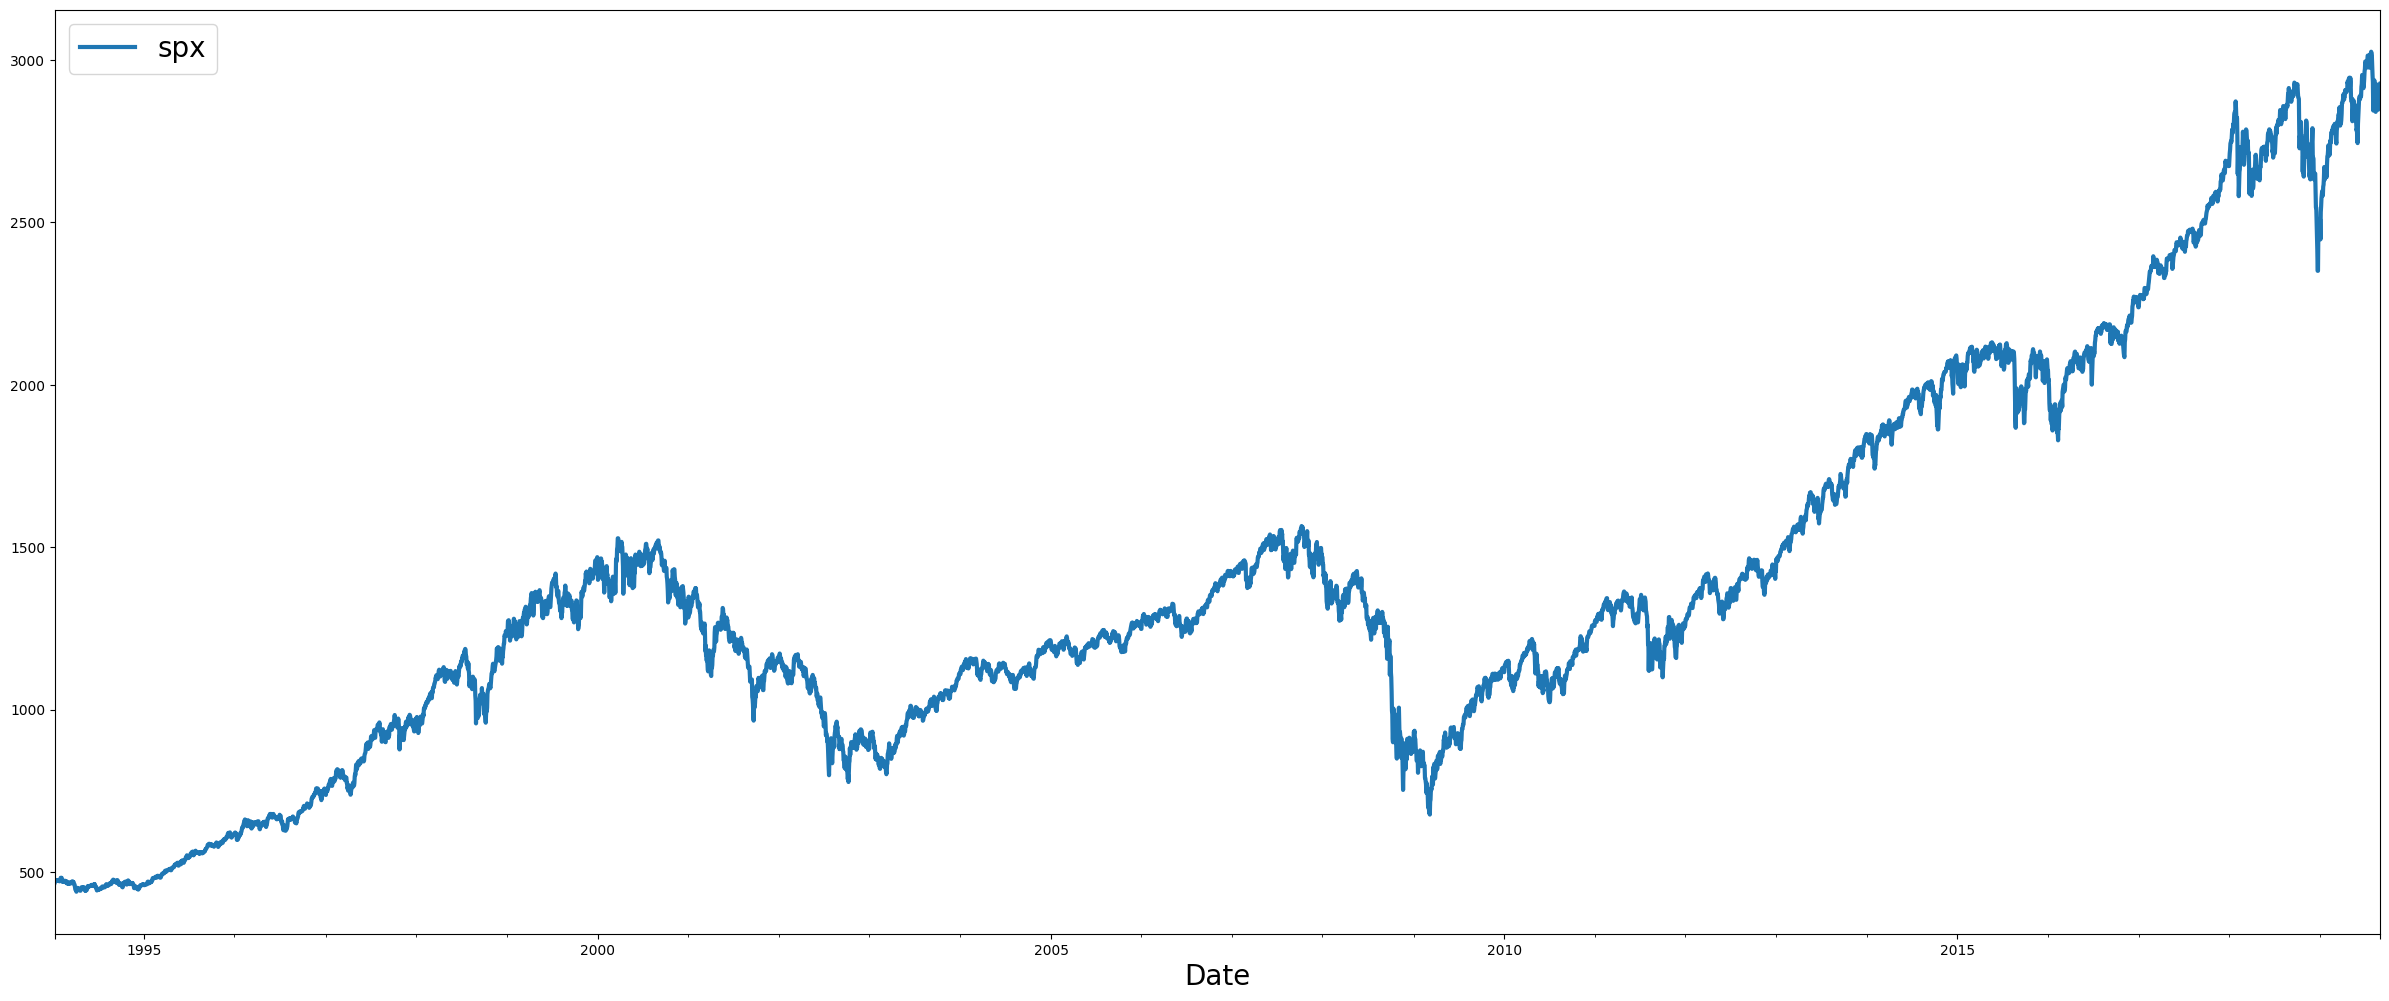

In [ ]:
# Импортируем модуль pyplot из библиотеки matplotlib для создания графиков
from matplotlib import pyplot as plt

# Настройка, чтобы графики отображались внутри ячейки Jupyter Notebook
%matplotlib inline

# Устанавливаем размер графика: ширина 30 дюймов, высота 12 дюймов
plt.rcParams["figure.figsize"] = 30, 12

# Устанавливаем размер шрифта для текста на графике
plt.rcParams["font.size"] = 20

# Настраиваем размер шрифта для меток на осях X и Y, чтобы они были читаемы
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Устанавливаем толщину линий на графике для лучшей видимости
plt.rcParams["lines.linewidth"] = 3

# Построение графика для данных из DataFrame data, который мы загрузили ранее
data.plot()

# Отображение графика
plt.show()


In [ ]:
# Разделение данных на обучающую и тестовую выборки по временным рамкам

# Создаем обучающую выборку (train_df), включающую данные до 31 декабря 2018 года
train_df = data.loc[:"2018-12-31"]

# Создаем тестовую выборку (test_df), включающую данные с 1 января 2019 года
test_df = data.loc["2019-01-01":]

# Выводим размерности обучающей и тестовой выборок
train_df.shape, test_df.shape


((6518, 1), (174, 1))

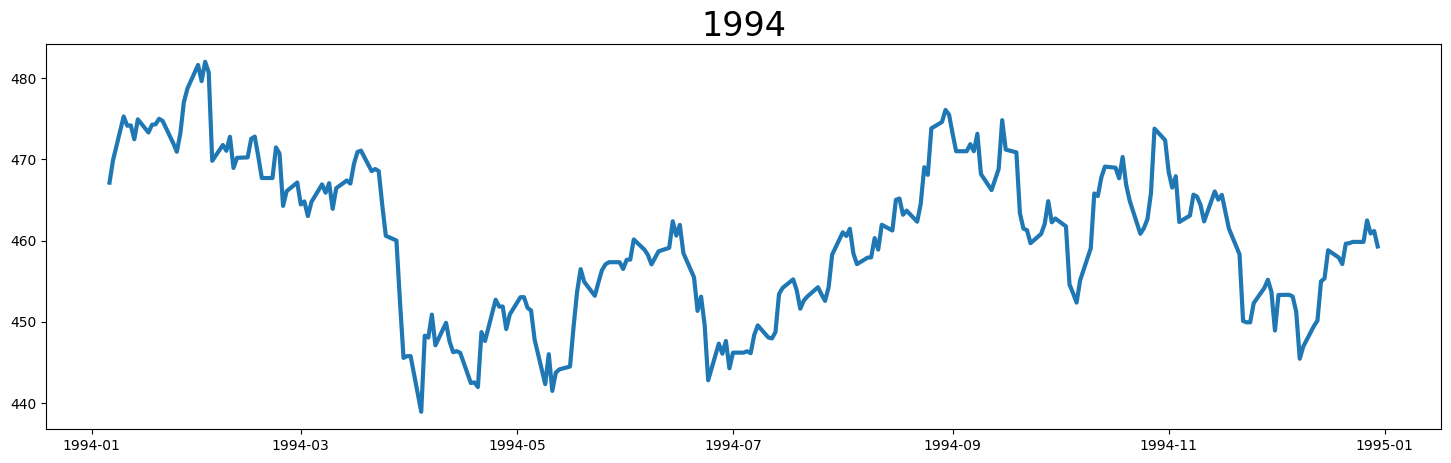

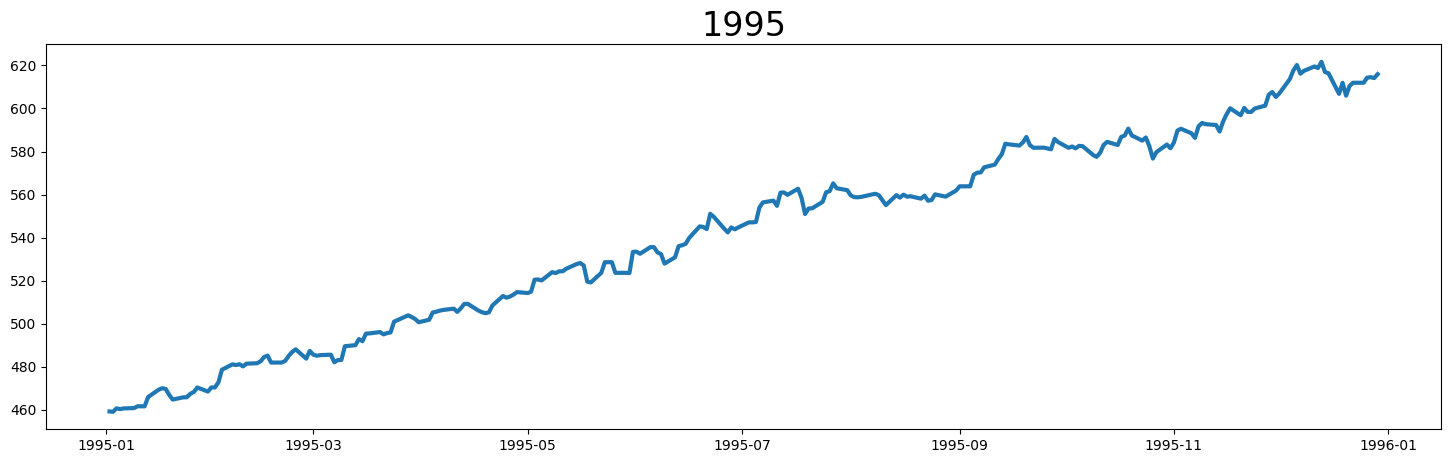

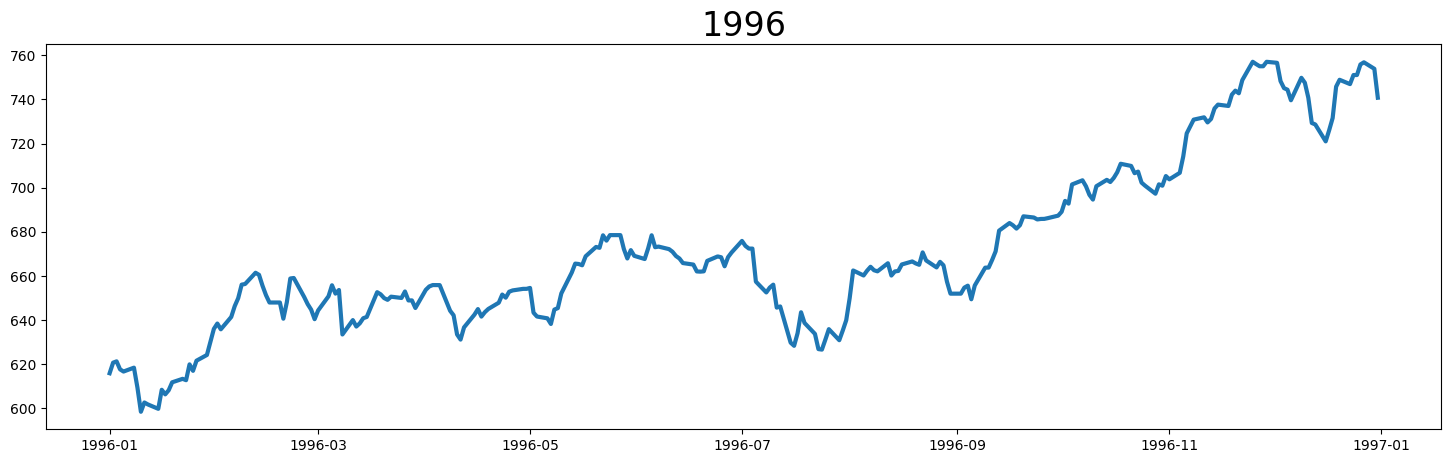

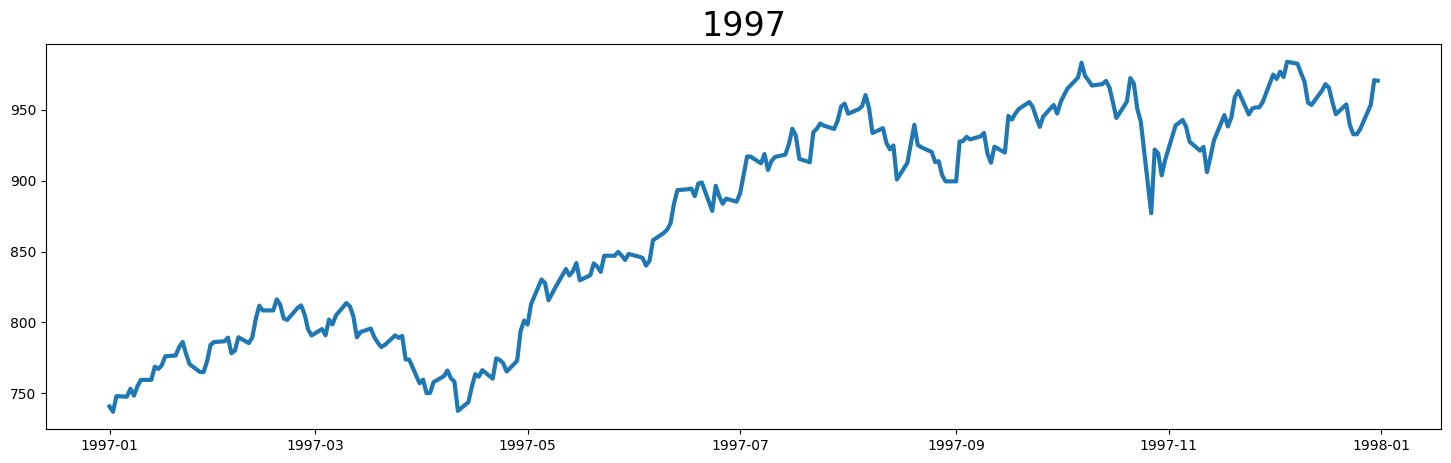

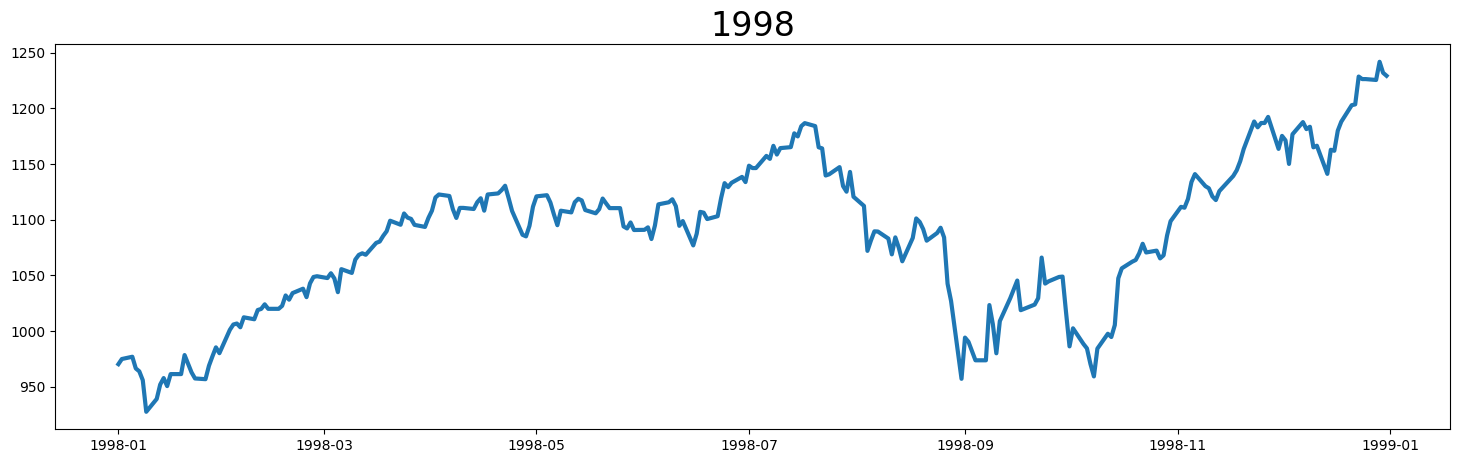

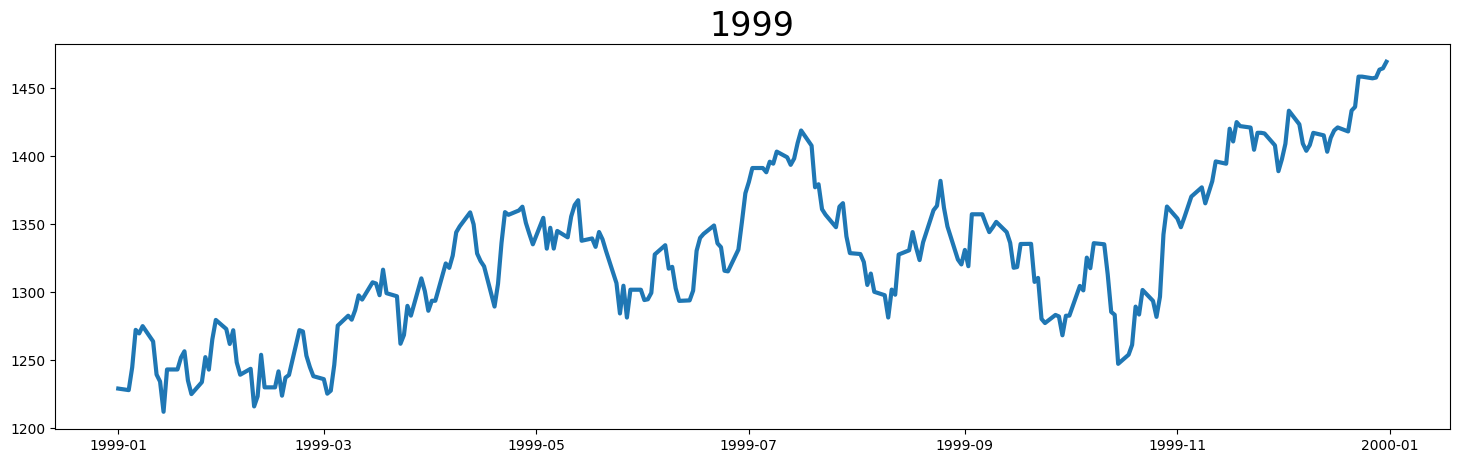

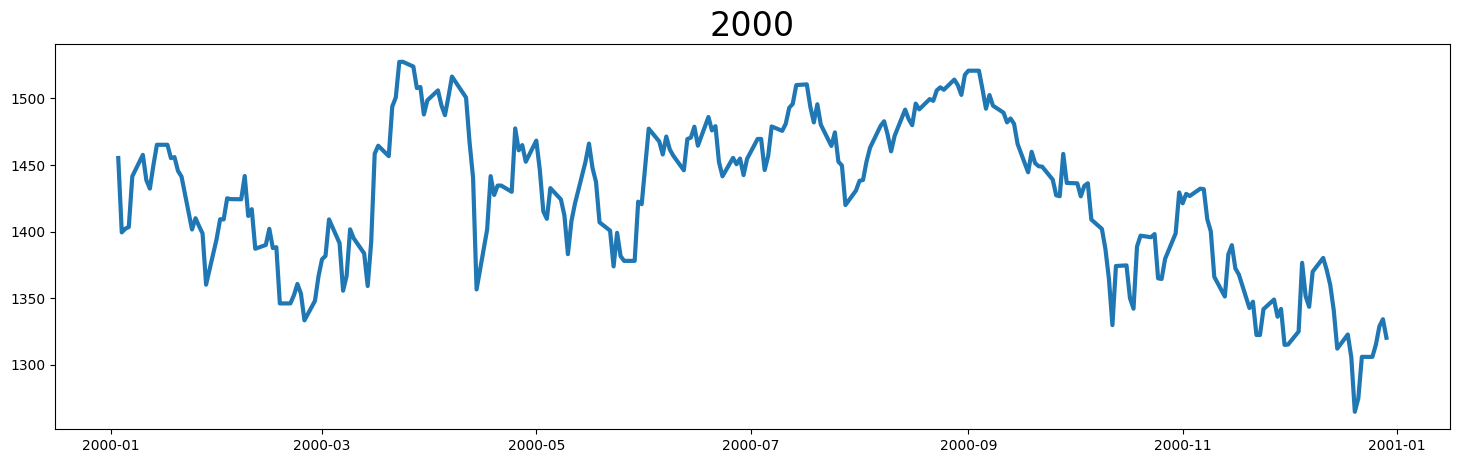

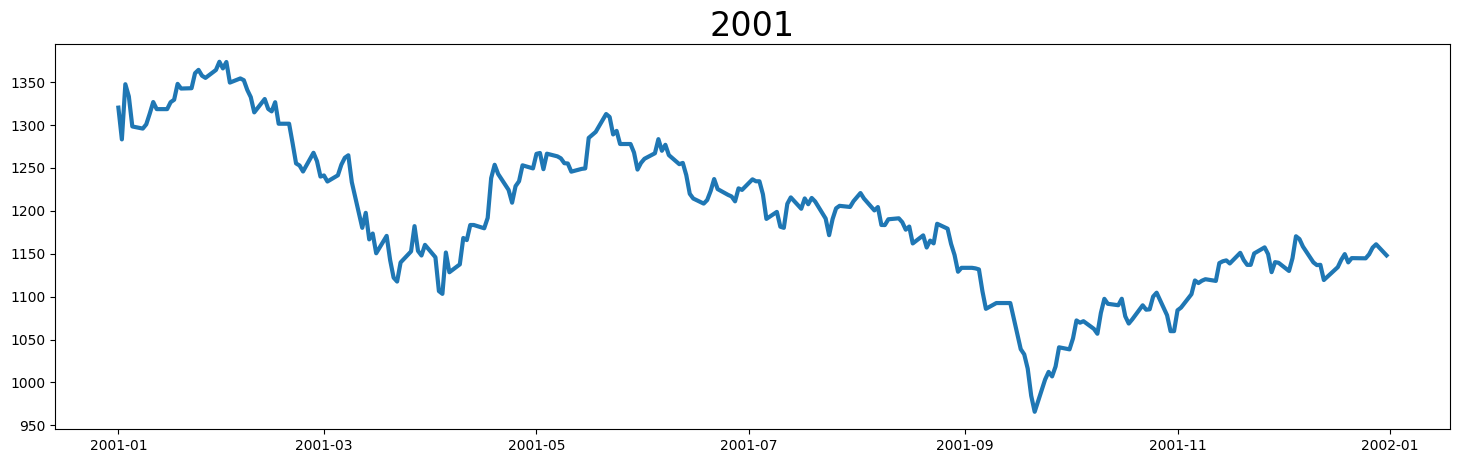

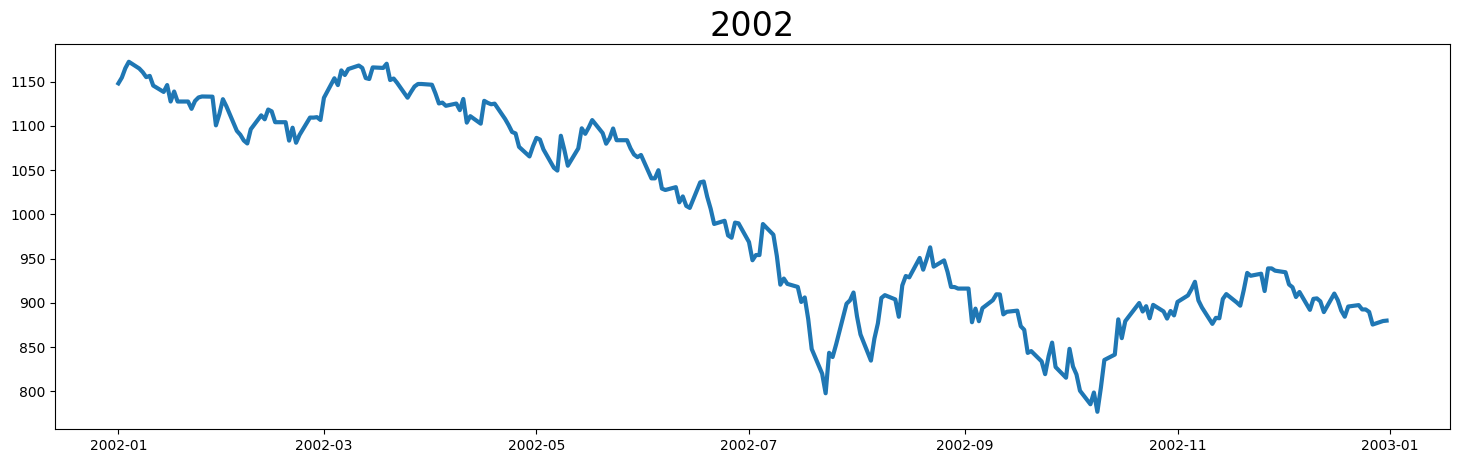

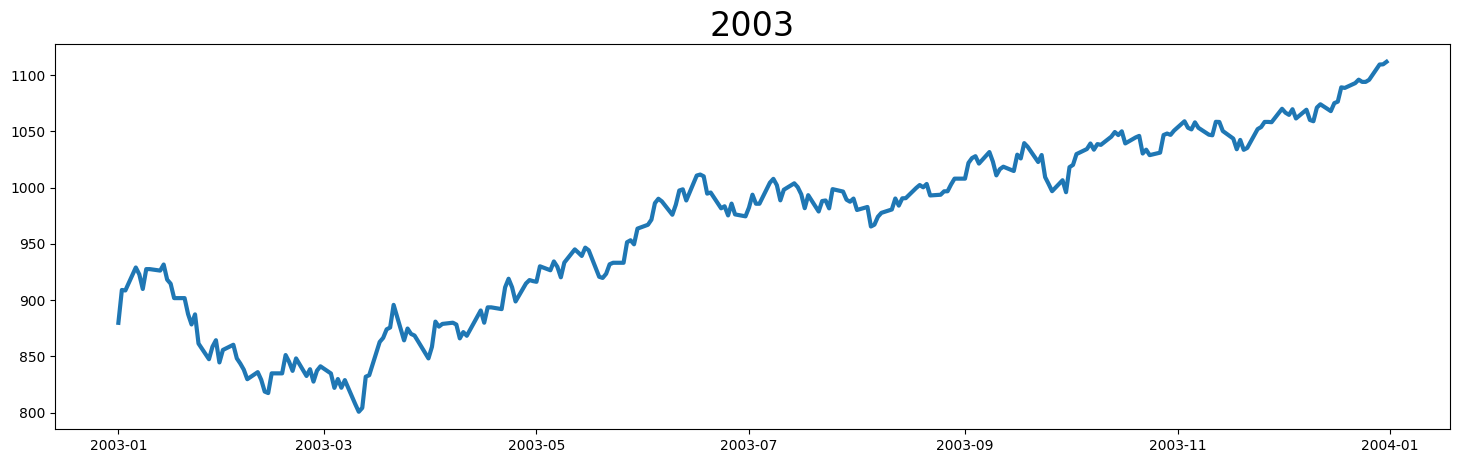

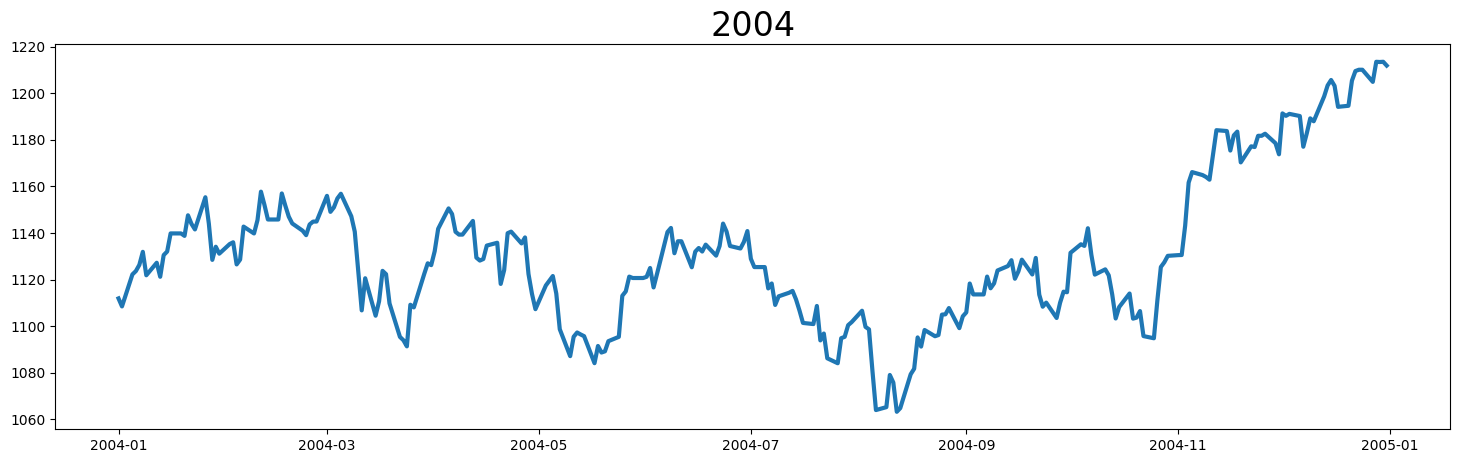

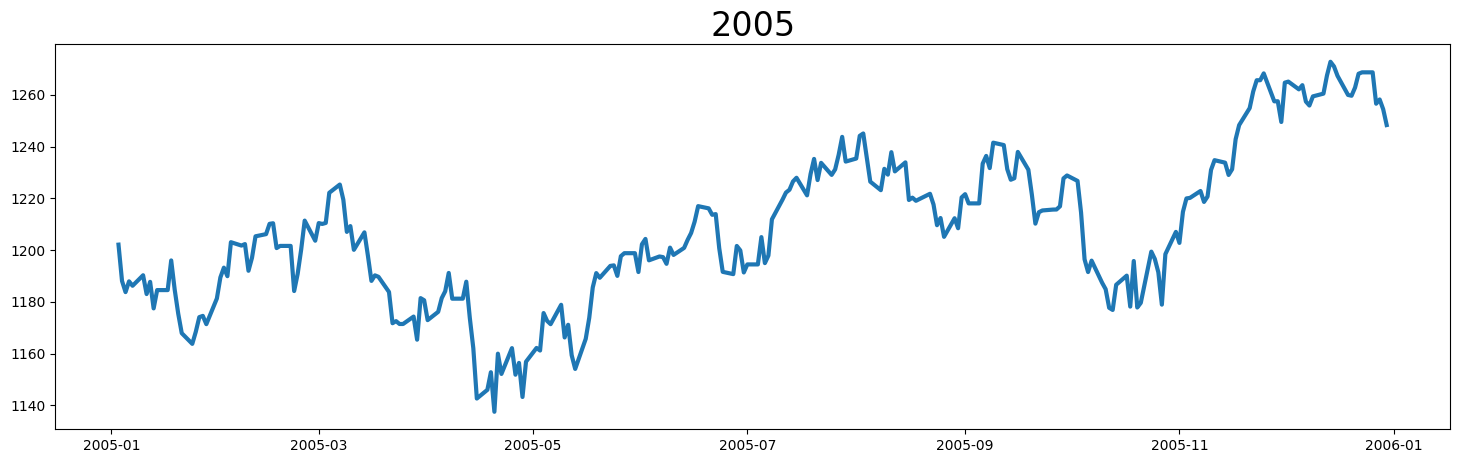

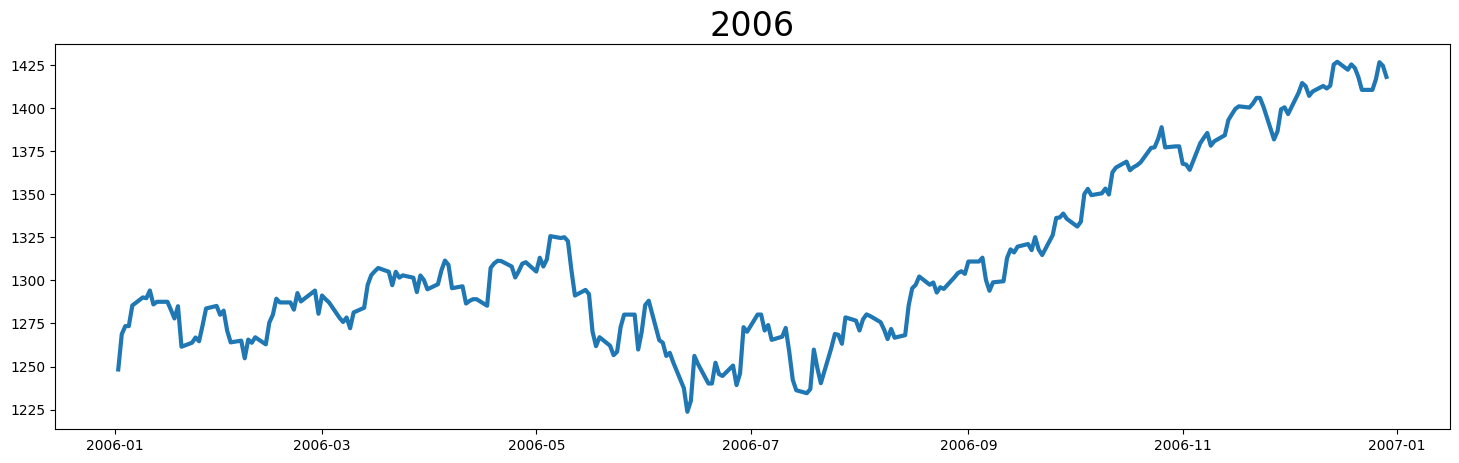

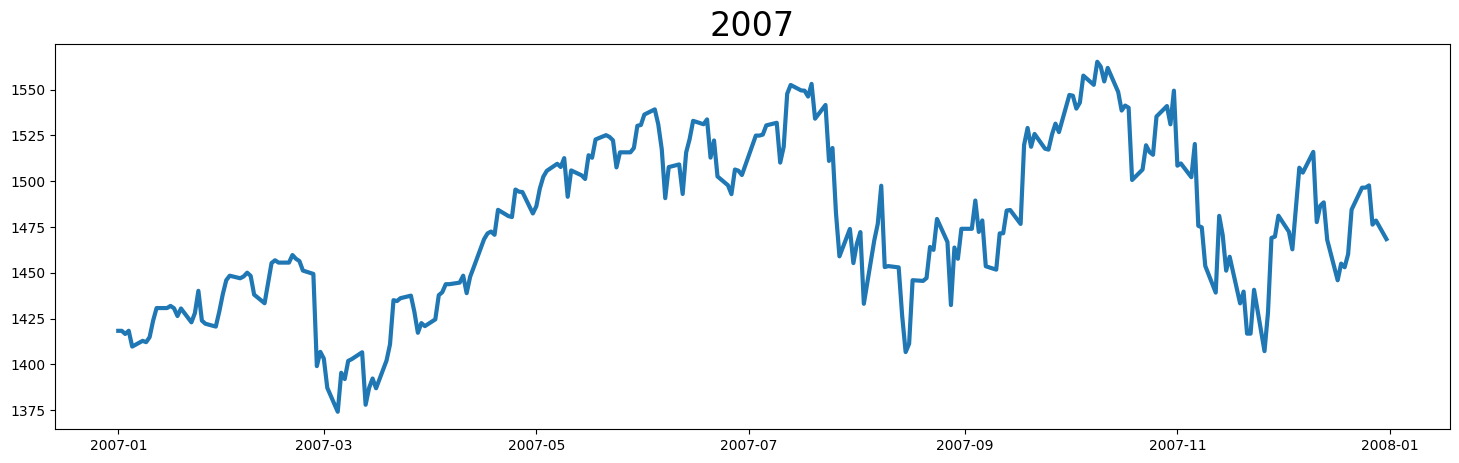

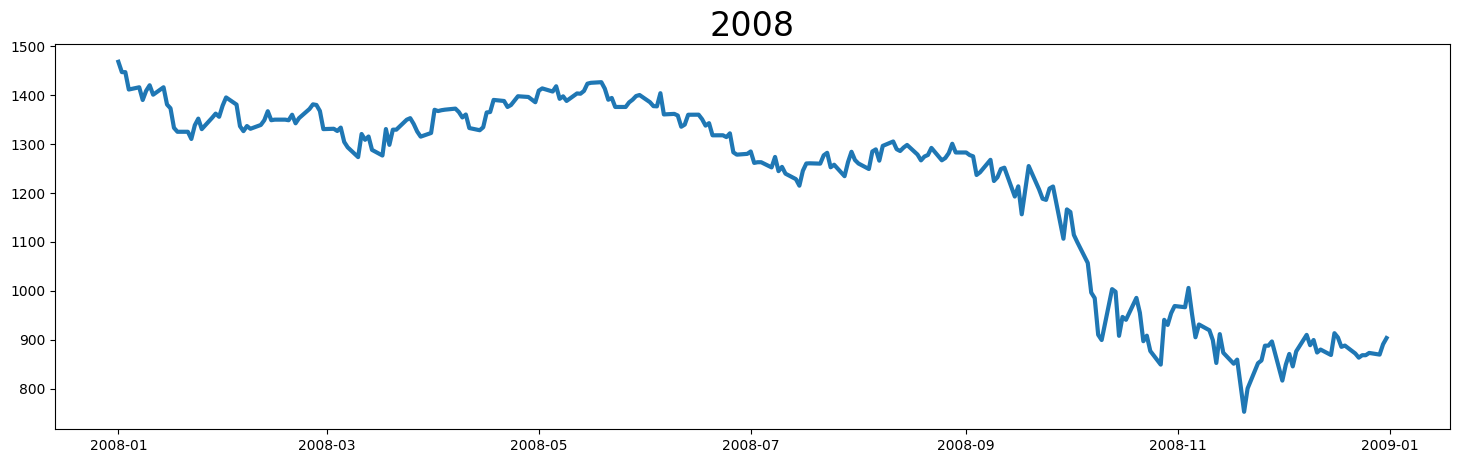

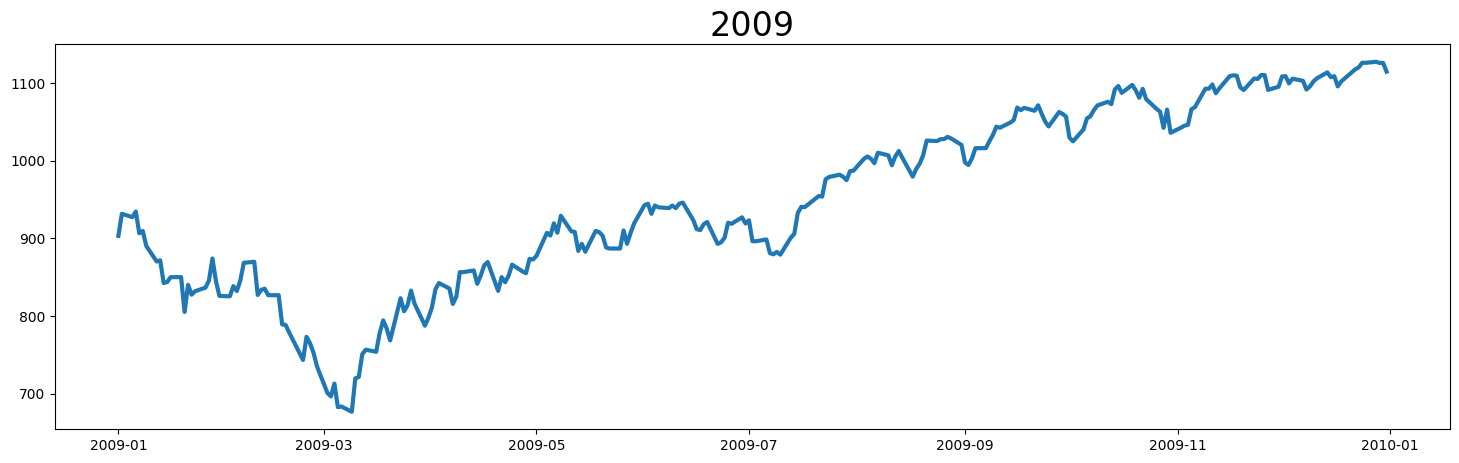

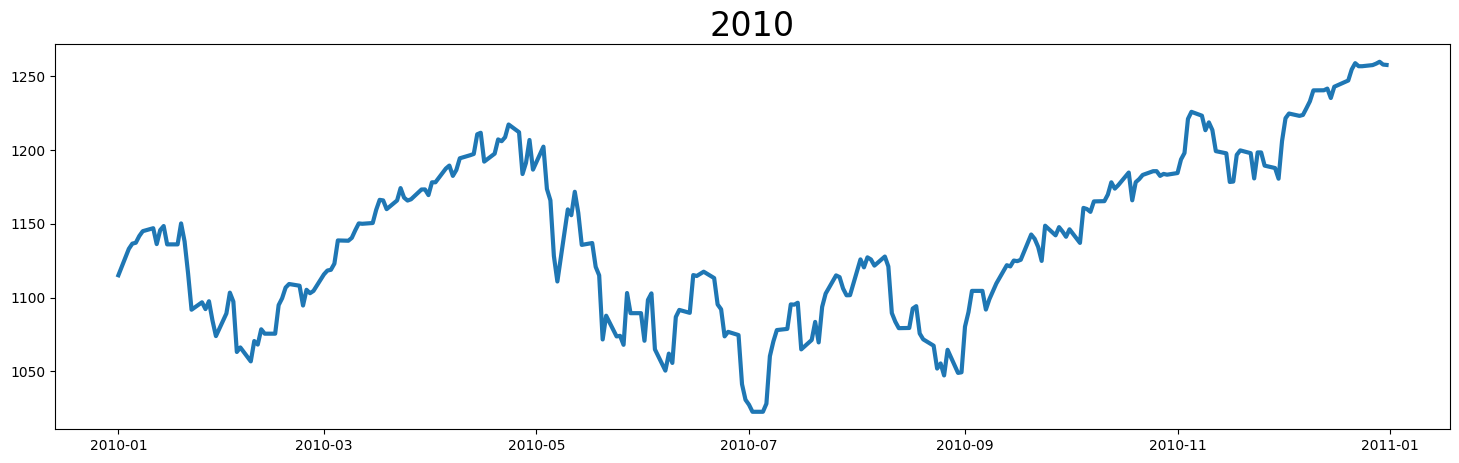

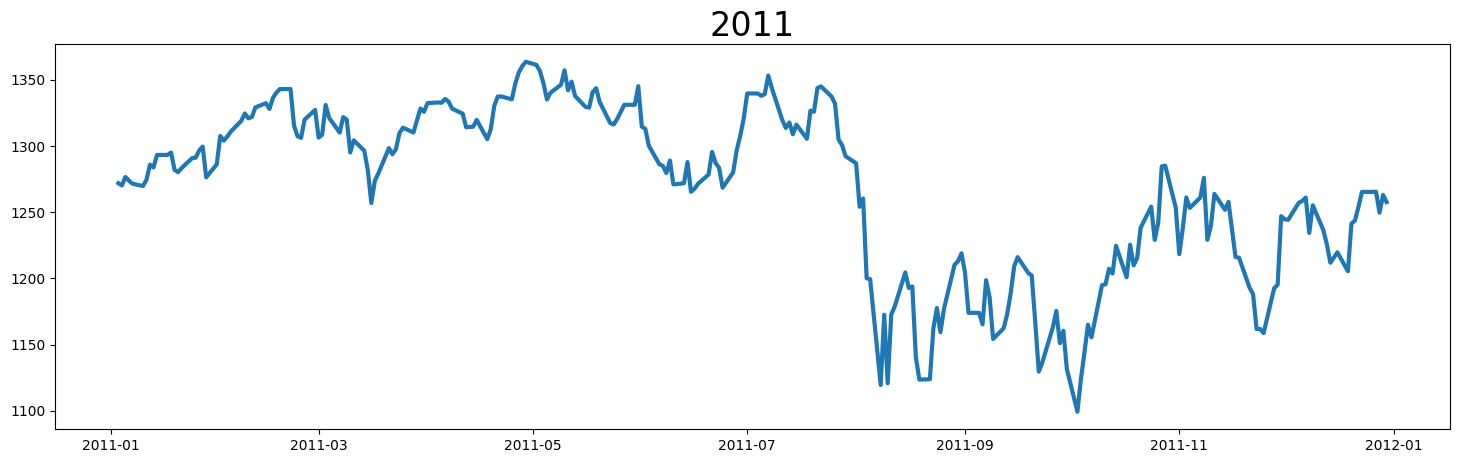

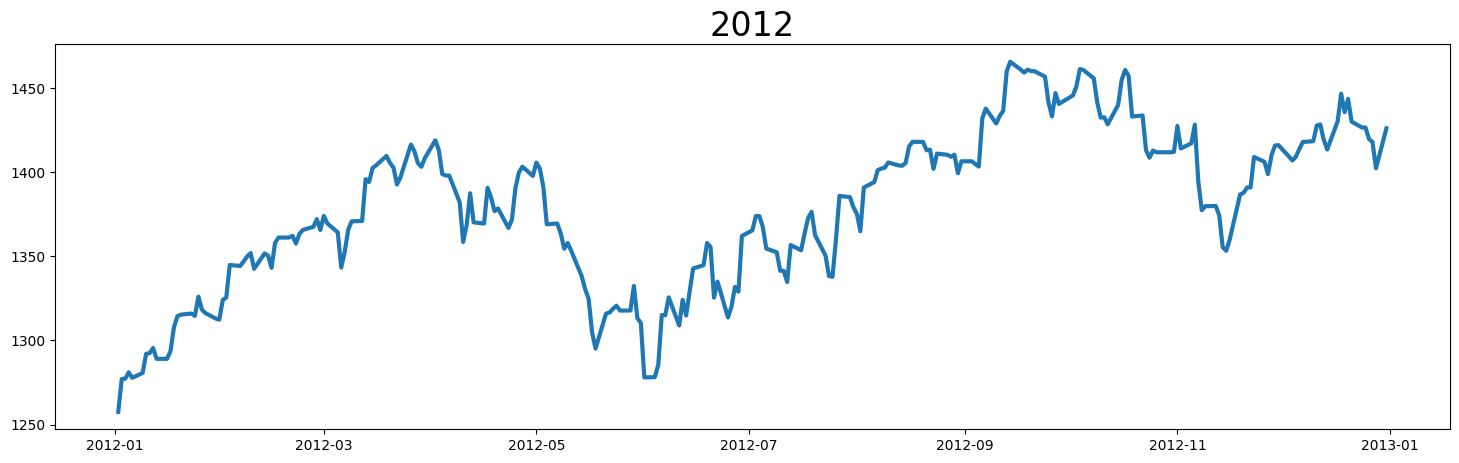

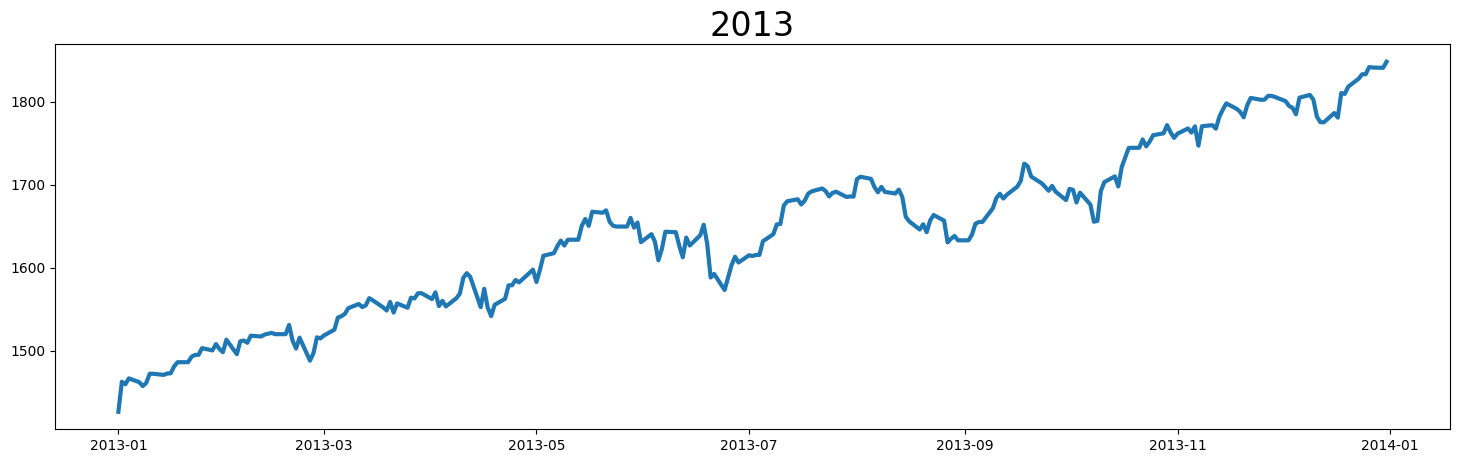

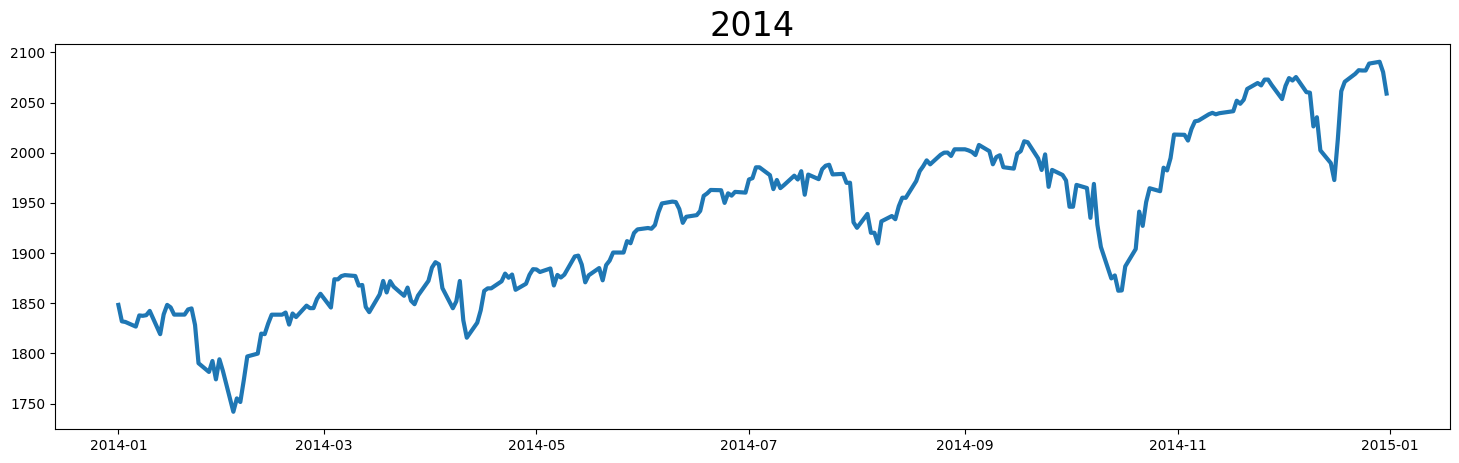

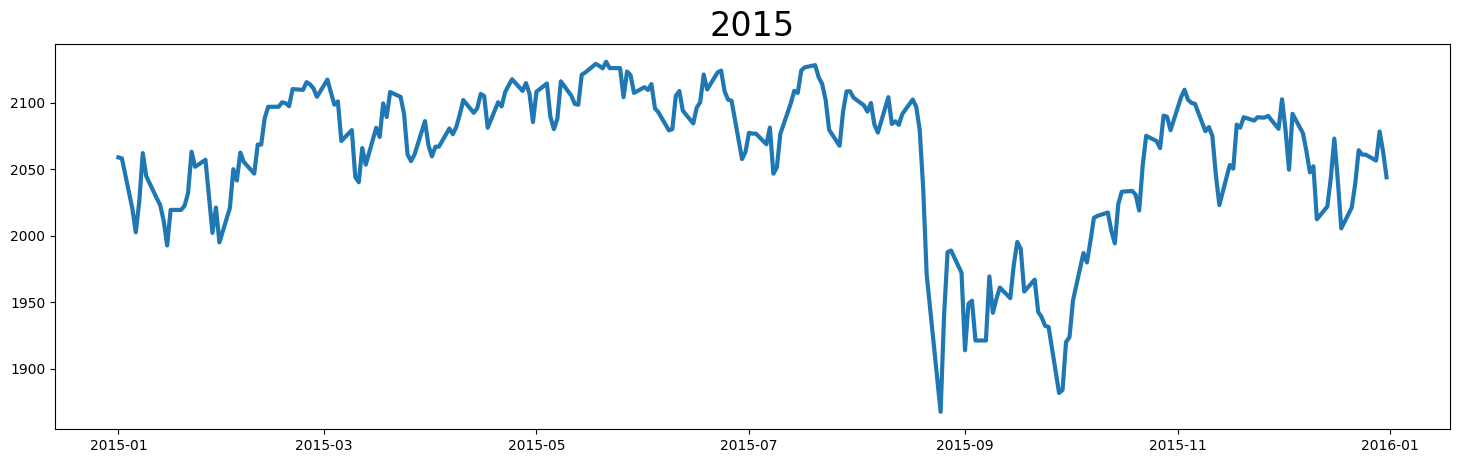

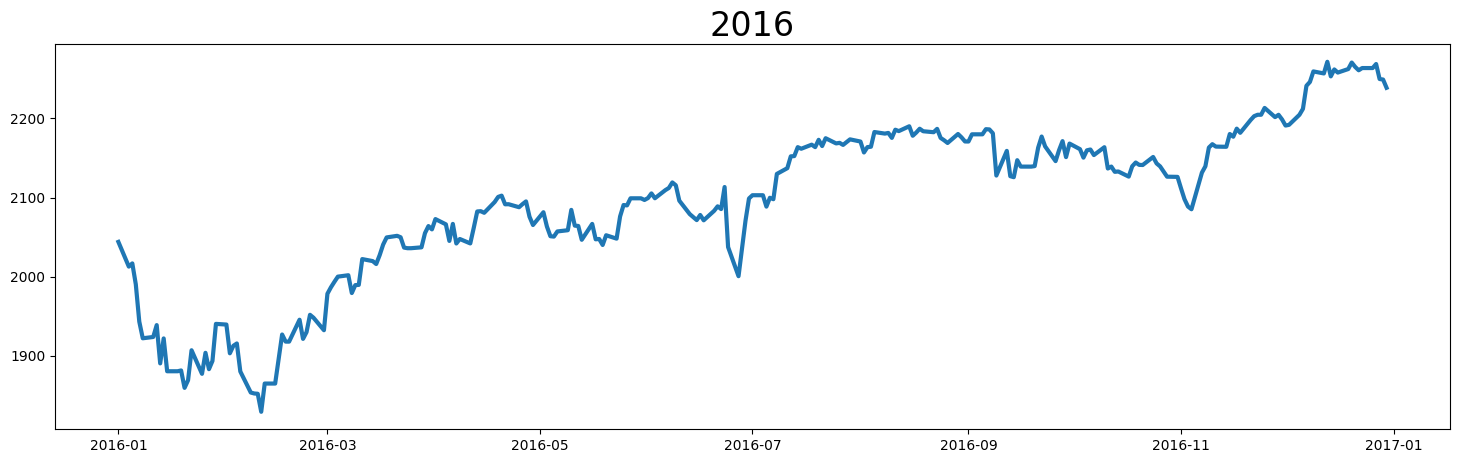

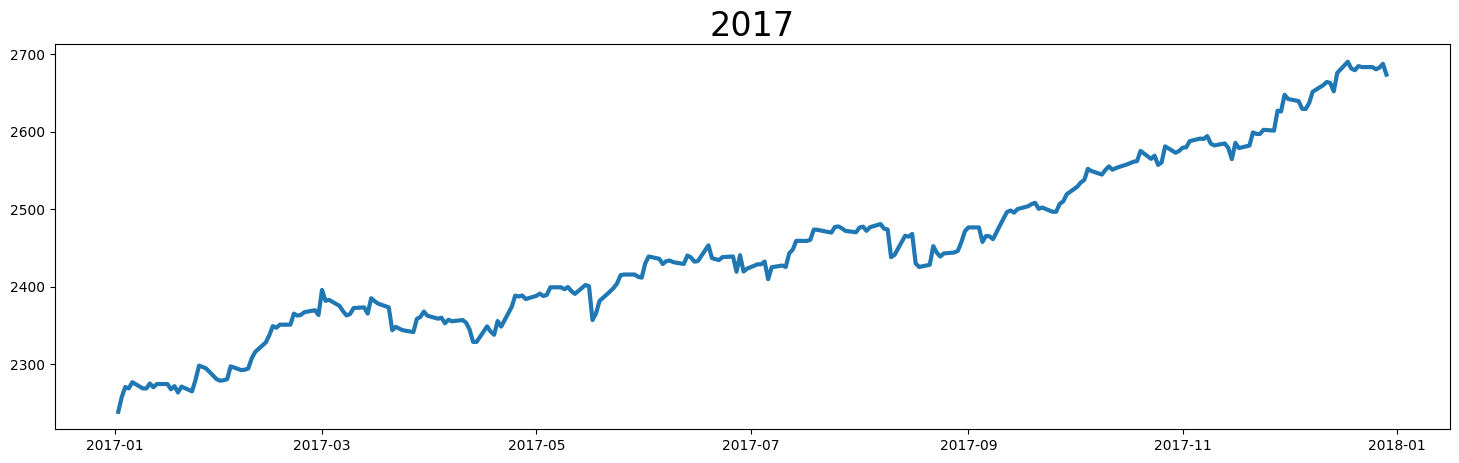

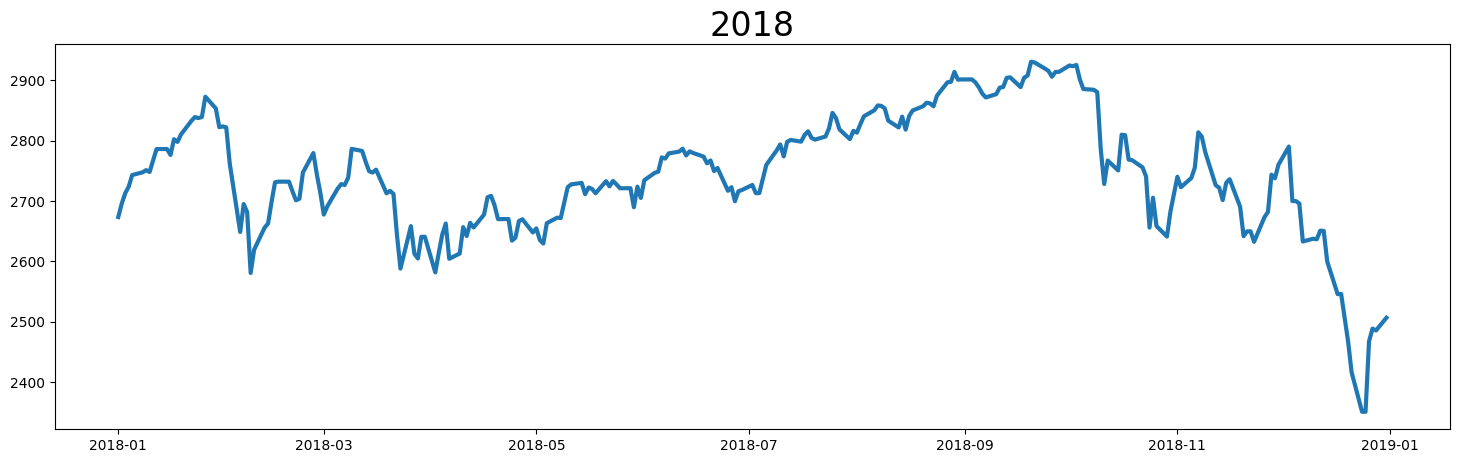

In [ ]:
# Устанавливаем размер графика для улучшенного визуального отображения отдельных годов
plt.rcParams["figure.figsize"] = 18, 5

# Перебираем уникальные года в индексе данных обучающей выборки (train_df)
for year in set(train_df.index.year):
    # Строим график для столбца "spx" за каждый год отдельно
    plt.plot(train_df[["spx"]].loc[train_df.index.year == year])

    # Устанавливаем заголовок графика, соответствующий текущему году, с размером шрифта 24
    plt.title(str(year), size=24)

    # Отображаем график, чтобы каждый год выводился отдельно
    plt.show()


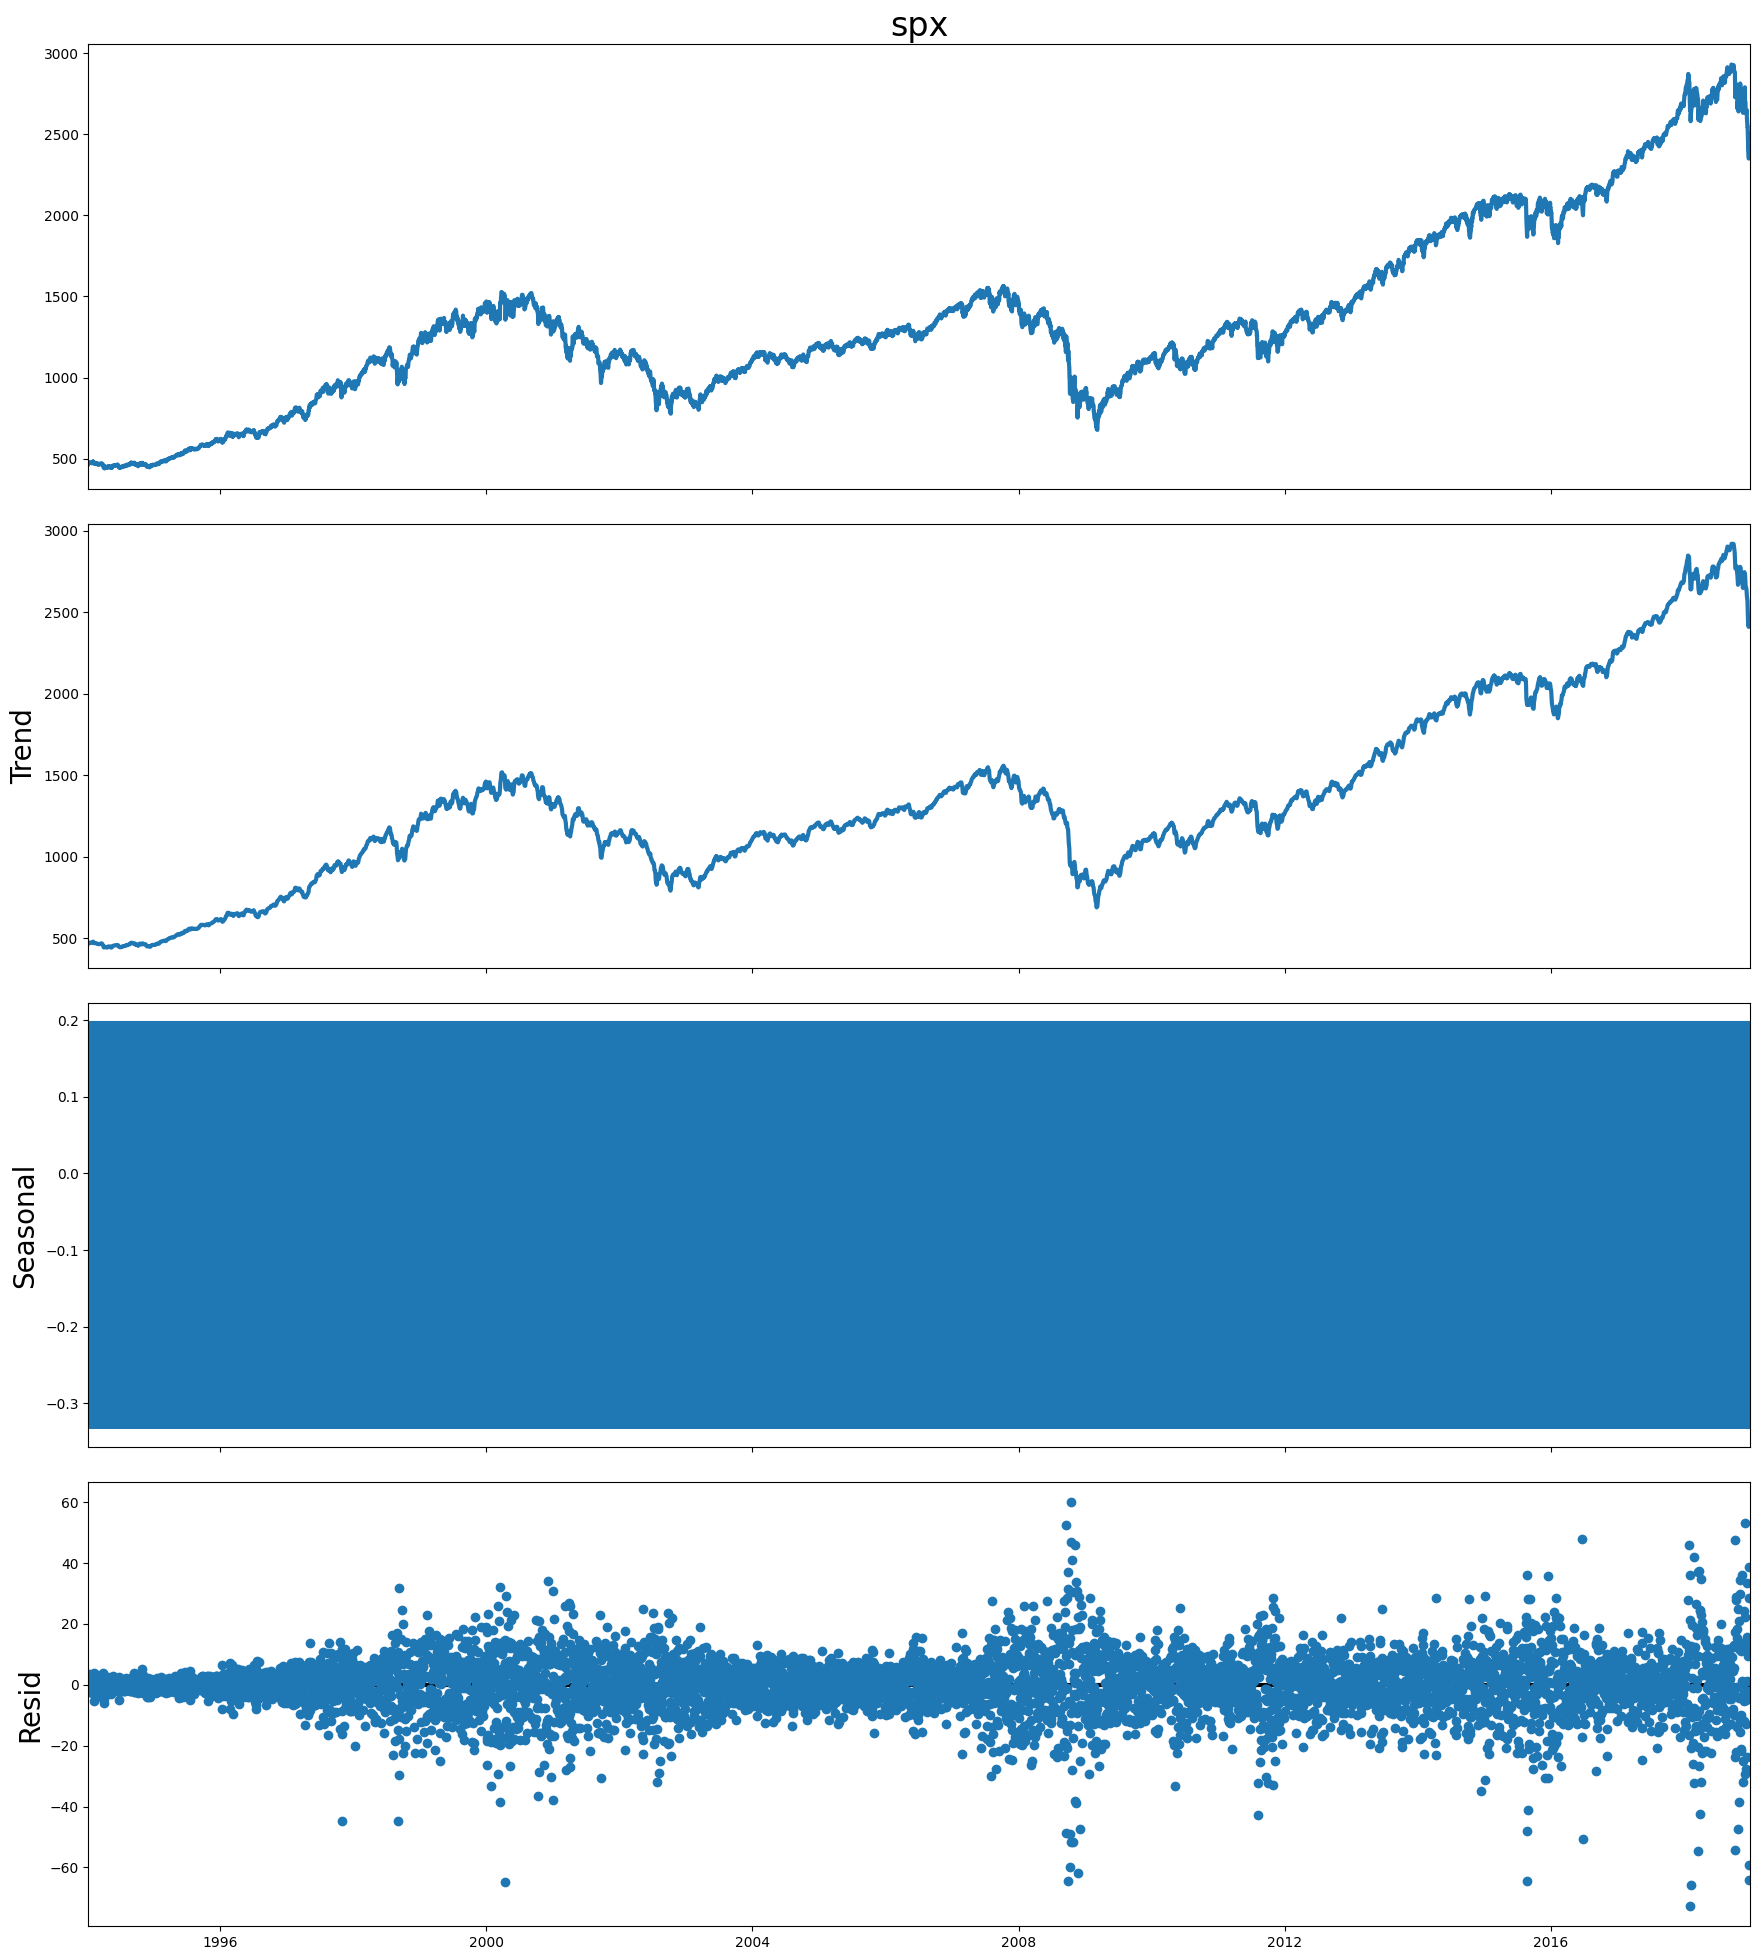

In [ ]:
# Импортируем функцию seasonal_decompose из модуля statsmodels для анализа сезонности временных рядов
from statsmodels.tsa.seasonal import seasonal_decompose

# Устанавливаем размер графика для наглядного отображения результатов декомпозиции
plt.rcParams["figure.figsize"] = 18, 20

# Выполняем декомпозицию временного ряда "spx" из обучающей выборки (train_df)
# Метод seasonal_decompose разделяет ряд на тренд, сезонность и остаточную компоненту
result = seasonal_decompose(train_df.spx)

# Строим графики для каждой компоненты декомпозиции (тренд, сезонность, остаток)
result.plot()

# Отображаем график
plt.show()


Сезонная компонента выглядит очень странно, посмотрим на первые 20 значений

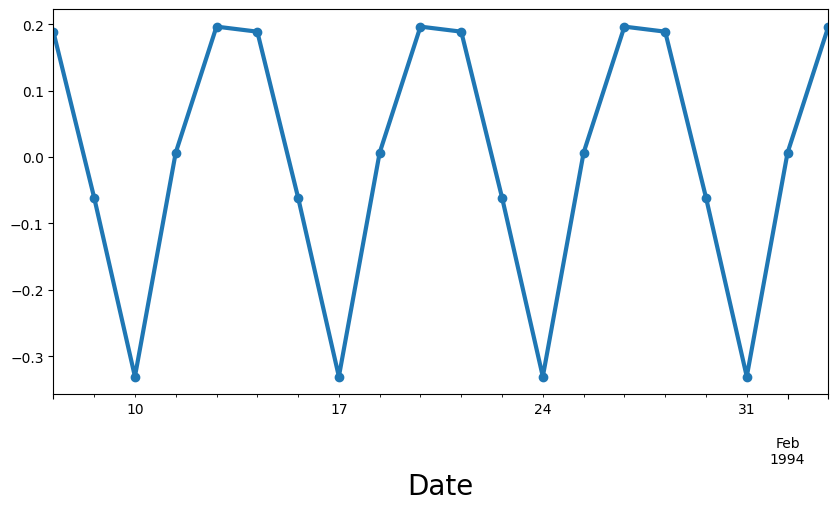

In [ ]:
# Устанавливаем размер графика для отображения сезонной компоненты временного ряда
plt.rcParams["figure.figsize"] = 10, 5

# Строим график первых 20 значений сезонной компоненты,
# чтобы рассмотреть циклические колебания на начальном отрезке данных
# Используем маркеры ("o") для выделения точек на графике
result.seasonal[:20].plot(marker="o")

# Отображаем график
plt.show()


График четко показывает повторяющийся цикл каждые 5 периодов. Это довольно логично, поскольку наши данные — это данные о ценах на акции. Мы наблюдаем и собираем данные о ценах на акции каждый рабочий день недели. Это означает, что данные представляли собой еженедельную сезонность, а неделя была рабочей неделей (5 дней в неделю)

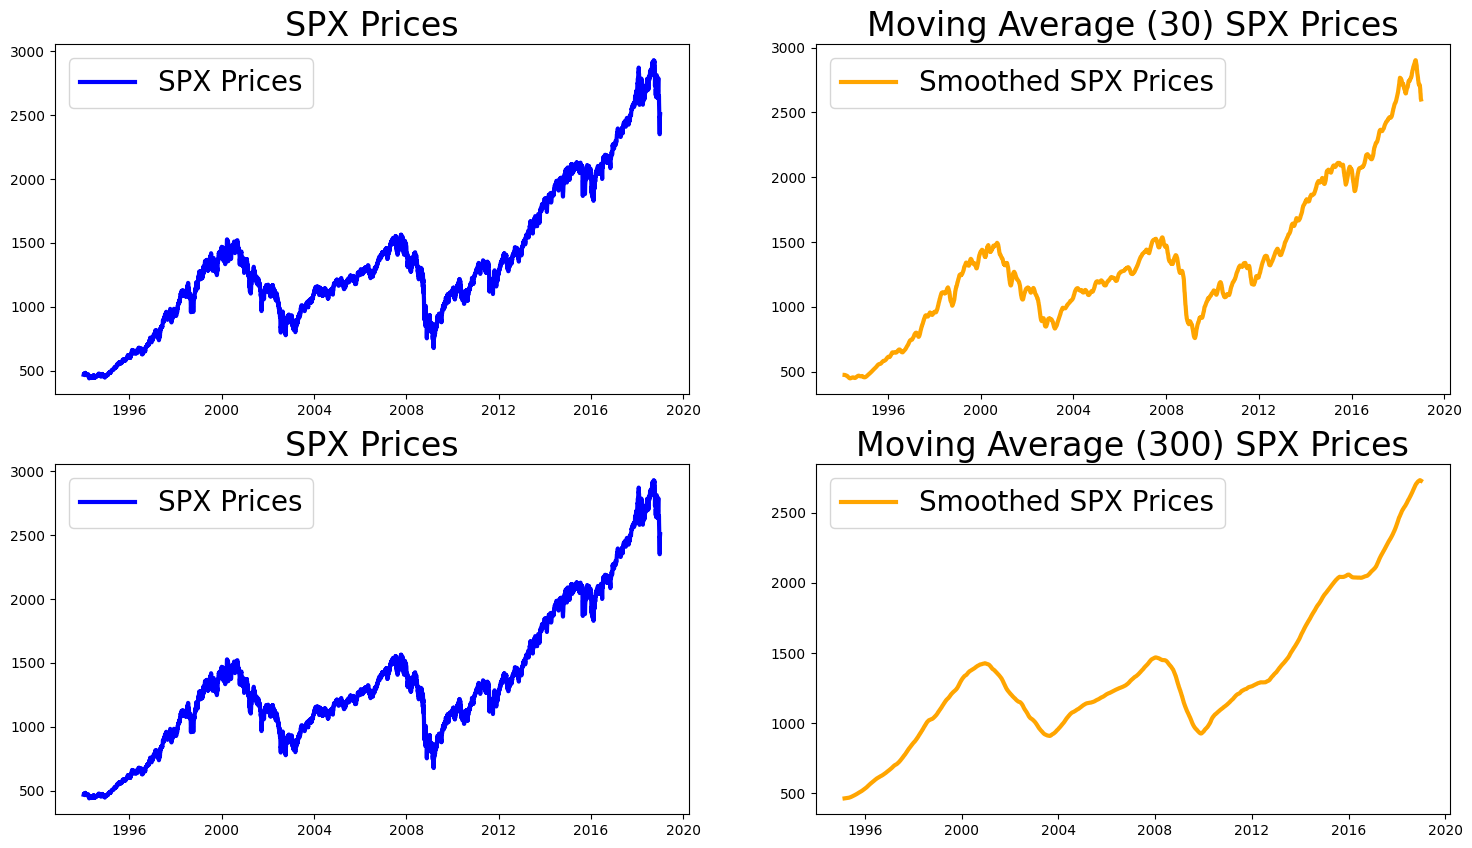

In [ ]:
# Устанавливаем размер фигуры для удобного отображения всех подграфиков
plt.rcParams["figure.figsize"] = 18, 10

# Создаем сетку из 2x2 подграфиков
fig, ax = plt.subplots(2, 2)

# Построение графиков с использованием разных окон скользящего среднего

# График исходных цен SPX (окно в месяц - 30 дней)
ax[0, 0].plot(train_df.spx, color="blue", label="SPX Prices")
ax[0, 0].set_title("SPX Prices", size=24)
ax[0, 0].legend()

# График скользящего среднего с окном 30 дней (1 месяц) для цен SPX
ax[0, 1].plot(
    train_df.spx.rolling(window=30).mean(),
    color="orange",
    label="Smoothed SPX Prices",
)
ax[0, 1].set_title("Moving Average (30) SPX Prices", size=24)
ax[0, 1].legend()

# График исходных цен SPX (окно в год - 300 дней)
ax[1, 0].plot(train_df.spx, color="blue", label="SPX Prices")
ax[1, 0].set_title("SPX Prices", size=24)
ax[1, 0].legend()

# График скользящего среднего с окном 300 дней (приблизительно 1 год) для цен SPX
ax[1, 1].plot(
    train_df.spx.rolling(window=300).mean(),
    color="orange",
    label="Smoothed SPX Prices",
)
ax[1, 1].set_title("Moving Average (300) SPX Prices", size=24)
ax[1, 1].legend()

# Отображение всех графиков
plt.show()


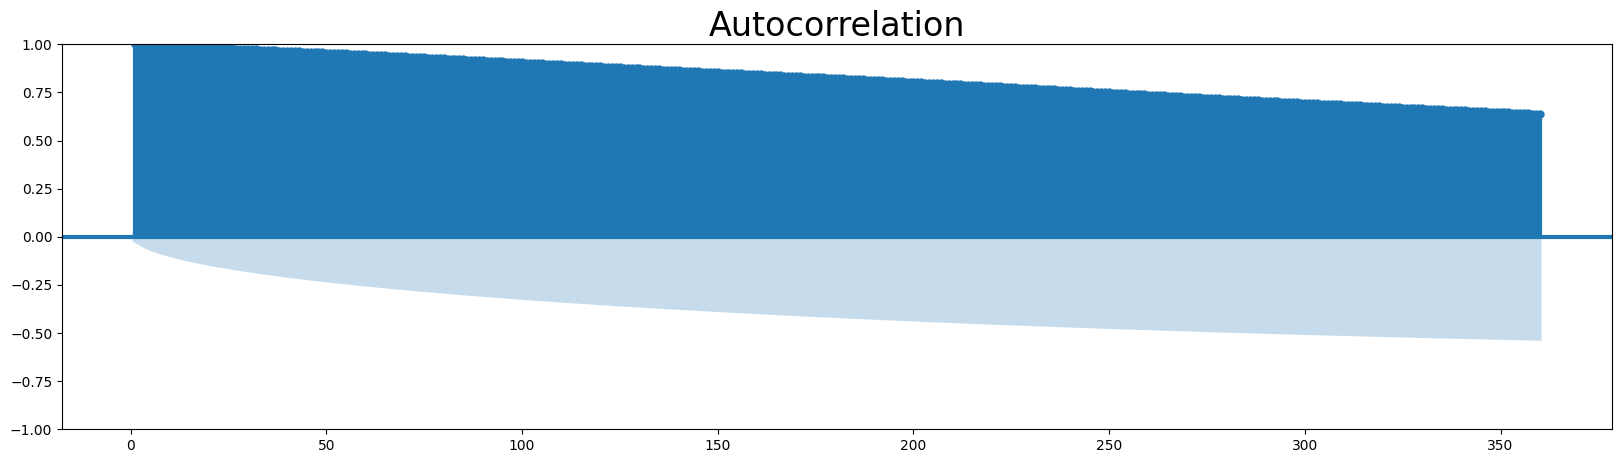

In [ ]:
# Импортируем модуль tsaplots из библиотеки statsmodels для построения автокорреляционных графиков
import statsmodels.graphics.tsaplots as sgt

# Устанавливаем размер графика для наглядного отображения автокорреляции
plt.rcParams["figure.figsize"] = 20, 5

# Построение графика автокорреляционной функции (ACF) для временного ряда "spx" из обучающей выборки
# Параметр lags=360 указывает, что анализируем автокорреляцию с лагом до 360 дней
# Параметр zero=False убирает корреляцию с нулевым лагом (т.е. автокорреляцию самой с собой)
sgt.plot_acf(train_df.spx, lags=360, zero=False)

# Отображение графика
plt.show()


Цены SPX сильно коррелированы. Корреляция сохраняется даже по прошествии года.

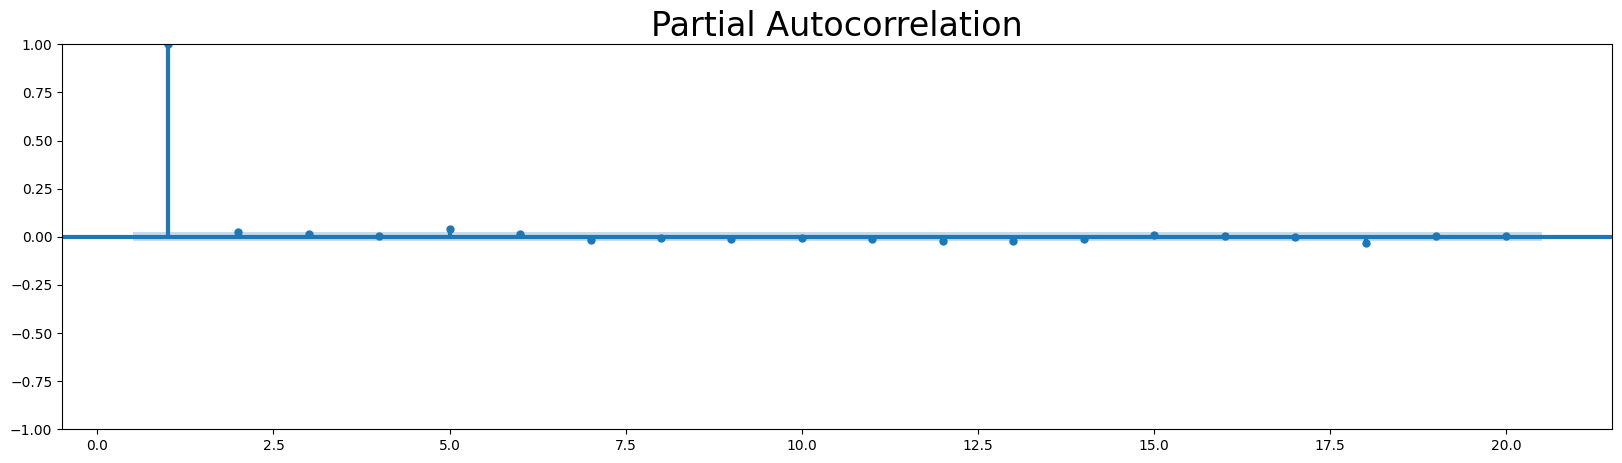

In [ ]:
# Импортируем модуль tsaplots из библиотеки statsmodels для построения графиков частичной автокорреляции
import statsmodels.graphics.tsaplots as sgt

# Устанавливаем размер графика для наглядного отображения частичной автокорреляции
plt.rcParams["figure.figsize"] = 20, 5

# Построение графика частичной автокорреляционной функции (PACF) для временного ряда "spx" из обучающей выборки
# Параметр lags=20 указывает, что анализируем частичную автокорреляцию с лагами до 20
# Параметр method="ywm" выбирает метод вычисления PACF (Yule-Walker method)
# Параметр zero=False убирает корреляцию с нулевым лагом
sgt.plot_pacf(train_df.spx, lags=20, method="ywm", zero=False)

# Отображение графика
plt.show()


Эти графики показывают, как данные коррелируют с запаздывающей версией самих себя.
В отличие от того, что предлагали графики ACF, цены SPX с лагом не приносят никакой новой информации. В таких ситуация параметр p выбирается =1


In [ ]:
# Импортируем функцию adfuller из библиотеки statsmodels для выполнения теста на стационарность
from statsmodels.tsa.stattools import adfuller

# Применяем тест Дики-Фуллера (ADF) для проверки стационарности временного ряда "spx" из обучающей выборки
# Тест проверяет, является ли ряд стационарным (проверка на наличие единичного корня)
adfuller(train_df["spx"])


(-0.33128093969652406,
 0.9209556878912157,
 10,
 6507,
 {'1%': -3.4313553606207843,
  '5%': -2.8619842833301883,
  '10%': -2.56700648865667},
 53000.32567590042)

In [ ]:
# Выполняем тест Дики-Фуллера (ADF) для проверки стационарности временного ряда "spx" из обучающей выборки
test1 = adfuller(train_df["spx"])

# Выводим статистику теста (ADF statistic)
print("adf: ", test1[0])

# Выводим p-value теста
print("p-value: ", test1[1])

# Выводим критические значения для различных уровней значимости
print("Critical values: ", test1[4])

# Сравниваем статистику теста с критическим значением на уровне 5% (для подтверждения стационарности)
if test1[0] > test1[4]["5%"]:
    print("ряд нестационарен")  # Если статистика больше критического значения, ряд нестационарен
else:
    print("ряд стационарен")  # Если статистика меньше или равна критическому значению, ряд стационарен


adf:  -0.33128093969652406
p-value:  0.9209556878912157
Critical values:  {'1%': -3.4313553606207843, '5%': -2.8619842833301883, '10%': -2.56700648865667}
ряд нестационарен


Статистика теста больше всех критических значений, поэтому нулевую гипотезу ($H_0$) нельзя отвергнуть.

Поэтому цены SPX не являются стационарными

In [ ]:
# Функция для построения графиков автокорреляции (ACF) и частичной автокорреляции (PACF)
# для переданного временного ряда.
def plot_acf_pacf(series):
    # Устанавливаем размер графиков для наглядного отображения
    plt.rcParams["figure.figsize"] = 18, 5

    # Создаем сетку из 1 строки и 2 столбцов для размещения двух графиков
    fig, axes = plt.subplots(1, 2)

    # Строим график автокорреляционной функции (ACF) для временного ряда с лагами до 40
    sgt.plot_acf(series, ax=axes[0], lags=40)

    # Строим график частичной автокорреляционной функции (PACF) для временного ряда с лагами до 40
    # Используем метод Yule-Walker для вычисления PACF
    sgt.plot_pacf(series, ax=axes[1], lags=40, method="ywm")

    # Отображаем оба графика
    plt.show()


#### Дифференцирование ряда
$y\_new_t = y_t - y_{t-1}$

где:  
- $y\_new_t$: Дифференцированное значение ряда $t$
- $y_t$: Фактическое значение ряда $t$
- $y_{t-1}$: Фактическое значение ряда $t-1$

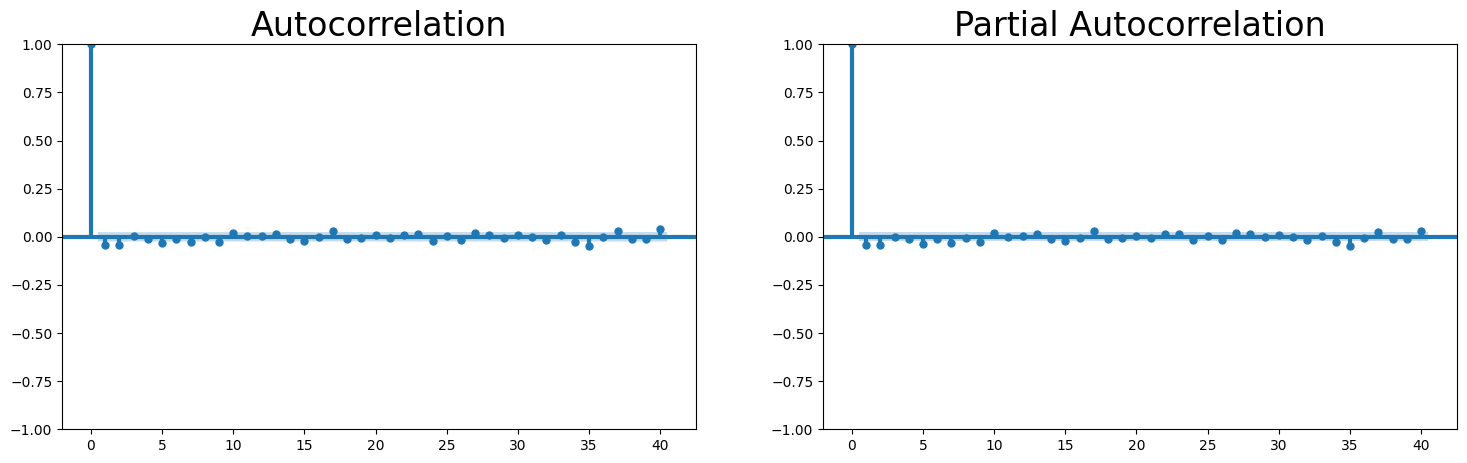

(-27.326250201731145,
 0.0,
 9,
 6507,
 {'1%': -3.4313553606207843,
  '5%': -2.8619842833301883,
  '10%': -2.56700648865667},
 52991.2781500849)

In [ ]:
# Строим графики ACF и PACF для дифференцированного временного ряда "spx"
# Дифференцирование (diff()) помогает сделать ряд стационарным
# dropna() используется для удаления значений NaN, которые могут возникать после дифференцирования
plot_acf_pacf(train_df["spx"].diff().dropna())

# Выполняем тест Дики-Фуллера (ADF) для проверки стационарности после дифференцирования
adfuller(train_df["spx"].diff().dropna())


Первые разности являются стационарными

#### ARIMA, SARIMA

Начнем построение модели **ARIMA** со следующими параметрами:

- p = 1
- d = 1
- q = 1

Если рассматривать сезонную модель (**SARMA**), то в модель можно добавить следующие параметры.

- m = 5 (будучи рыночным индексом, данные, скорее всего, будут иметь еженедельно повторяющиеся паттерны, как видно из визуализации)
- P = 1
- D = 1
- Q = 1

In [ ]:
# Импортируем модель ARIMA из библиотеки statsmodels для построения модели авторегрессии с интегрированием и скользящим средним
from statsmodels.tsa.arima.model import ARIMA

# Создаем модель ARIMA для временного ряда "spx" с порядком (1, 1, 1),
# где:
# - 1 - порядок авторегрессии (AR)
# - 1 - порядок дифференцирования (I), чтобы сделать ряд стационарным
# - 1 - порядок скользящего среднего (MA)
arima_model = ARIMA(train_df["spx"].dropna(), order=(1, 1, 1))

# Обучаем модель на данных
arima_model_fit = arima_model.fit()

# Выводим сводку по результатам обучения модели (коэффициенты модели, статистика)
arima_model_fit.summary()


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    spx   No. Observations:                 6518
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -26625.675
Date:                Sat, 09 Nov 2024   AIC                          53257.350
Time:                        20:25:11   BIC                          53277.697
Sample:                    01-06-1994   HQIC                         53264.387
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7598      0.048     15.908      0.000       0.666       0.853
ma.L1         -0.8016      0.044    -18.385      0.000      -0.887      -0.716
sigma2       207.1124      1.766    117.304      0.000     203.652     210.573
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):             12081.79
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               1.93   Skew:                            -0.62
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# Импортируем модель SARIMAX из библиотеки statsmodels для построения модели с сезонностью
# SARIMAX (Seasonal ARIMA with eXogenous regressors) расширяет ARIMA, добавляя поддержку сезонности и экзогенных переменных.
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Создаем модель SARIMAX для временного ряда "spx" с порядком (1, 1, 1),
# где:
# - 1 - порядок авторегрессии (AR)
# - 1 - порядок дифференцирования (I)
# - 1 - порядок скользящего среднего (MA)
model = SARIMAX(train_df["spx"].dropna(), order=(1, 1, 1))

# Обучаем модель на данных
model_fit = model.fit()

# Выводим сводку по результатам обучения модели (коэффициенты, статистика, ошибки)
model_fit.summary()


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    spx   No. Observations:                 6518
Model:               SARIMAX(1, 1, 1)   Log Likelihood              -26625.675
Date:                Sat, 09 Nov 2024   AIC                          53257.350
Time:                        20:25:13   BIC                          53277.697
Sample:                    01-06-1994   HQIC                         53264.387
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7598      0.048     15.908      0.000       0.666       0.853
ma.L1         -0.8016      0.044    -18.385      0.000      -0.887      -0.716
sigma2       207.1124      1.766    117.304      0.000     203.652     210.573
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):             12081.79
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               1.93   Skew:                            -0.62
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Как правило, модель с более высоким логарифмическим правдоподобием или более низким IC (AIC, BIC или HQIC) лучше, и наоборот.

In [ ]:
# Создаем модель SARIMAX для временного ряда "spx" с дополнительными сезонными компонентами
# В параметре order=(1, 1, 2):
# - 1 - порядок авторегрессии (AR)
# - 1 - порядок дифференцирования (I)
# - 2 - порядок скользящего среднего (MA)
# В параметре seasonal_order=(1, 1, 2, 5):
# - 1 - порядок сезонной авторегрессии (SAR)
# - 1 - порядок сезонного дифференцирования (SI)
# - 2 - порядок сезонного скользящего среднего (SMA)
# - 5 - длина сезонного цикла (например, 5 для сезонности в 5 периодов, что может быть годом, месяцем или неделей)
seas_model = SARIMAX(
    train_df["spx"].dropna(), order=(1, 1, 2), seasonal_order=(1, 1, 2, 5)
)

# Обучаем модель на данных
seas_model_fit = seas_model.fit()

# Выводим сводку по результатам обучения модели
seas_model_fit.summary()


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                               spx   No. Observations:                 6518
Model:             SARIMAX(1, 1, 2)x(1, 1, 2, 5)   Log Likelihood              -26617.829
Date:                           Sat, 09 Nov 2024   AIC                          53249.657
Time:                                   20:26:59   BIC                          53297.127
Sample:                               01-06-1994   HQIC                         53266.074
                                    - 12-31-2018                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1565      0.169      0.924      0.355      -0.175       0.488
ma.L1         -0.1993      0.169     -1.183      0.237      -0.530       0.131
ma.L2         -0.0333      0.011     -2.898      0.004      -0.056      -0.011
ar.S.L5       -0.7732      0.081     -9.558      0.000      -0.932      -0.615
ma.S.L5       -0.2578      0.085     -3.031      0.002      -0.425      -0.091
ma.S.L10      -0.7414      0.086     -8.656      0.000      -0.909      -0.574
sigma2       206.7707      1.991    103.839      0.000     202.868     210.674
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             11680.21
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.91   Skew:                            -0.57
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# Создаем новый DataFrame pred_df с индексом, соответствующим всему временному ряду
# для хранения предсказаний модели и реальных значений.
pred_df = pd.DataFrame(index=data.index)

# Получаем предсказания модели для тестового набора данных и добавляем их в pred_df.
# Предсказания начинаются с первого дня тестового набора и заканчиваются последним.
pred_df["model_preds"] = seas_model_fit.predict(
    start=test_df.index[0], end=test_df.index[-1]
)

# Добавляем реальные значения "spx" в pred_df для дальнейшего сравнения.
pred_df["spx"] = data["spx"]

# Получаем прогноз на тестовый набор данных (срок прогноза равен длине тестового набора).
forecast = seas_model_fit.get_forecast(len(test_df.index))

# Получаем доверительные интервалы (95%) для прогноза
forecast_df = forecast.conf_int(alpha=0.05)  # Доверительный уровень 95%

# Добавляем нижнюю и верхнюю границу доверительного интервала в pred_df для тестового набора
pred_df.at[test_df.index, "model_preds_lower"] = forecast_df["lower spx"]
pred_df.at[test_df.index, "model_preds_upper"] = forecast_df["upper spx"]


In [ ]:
pred_df

,model_preds,spx,model_preds_lower,model_preds_upper
Date,,,,
1994-01-06,NaN,467.119995,NaN,NaN
1994-01-07,NaN,469.899994,NaN,NaN
1994-01-10,NaN,475.269989,NaN,NaN
1994-01-11,NaN,474.130005,NaN,NaN
1994-01-12,NaN,474.170013,NaN,NaN
...,...,...,...,...
2019-08-26,2552.031307,2878.379883,2218.558476,2885.504138
2019-08-27,2552.690885,2869.159912,2218.212589,2887.169181
2019-08-28,2553.210885,2887.939941,2217.730215,2888.691555


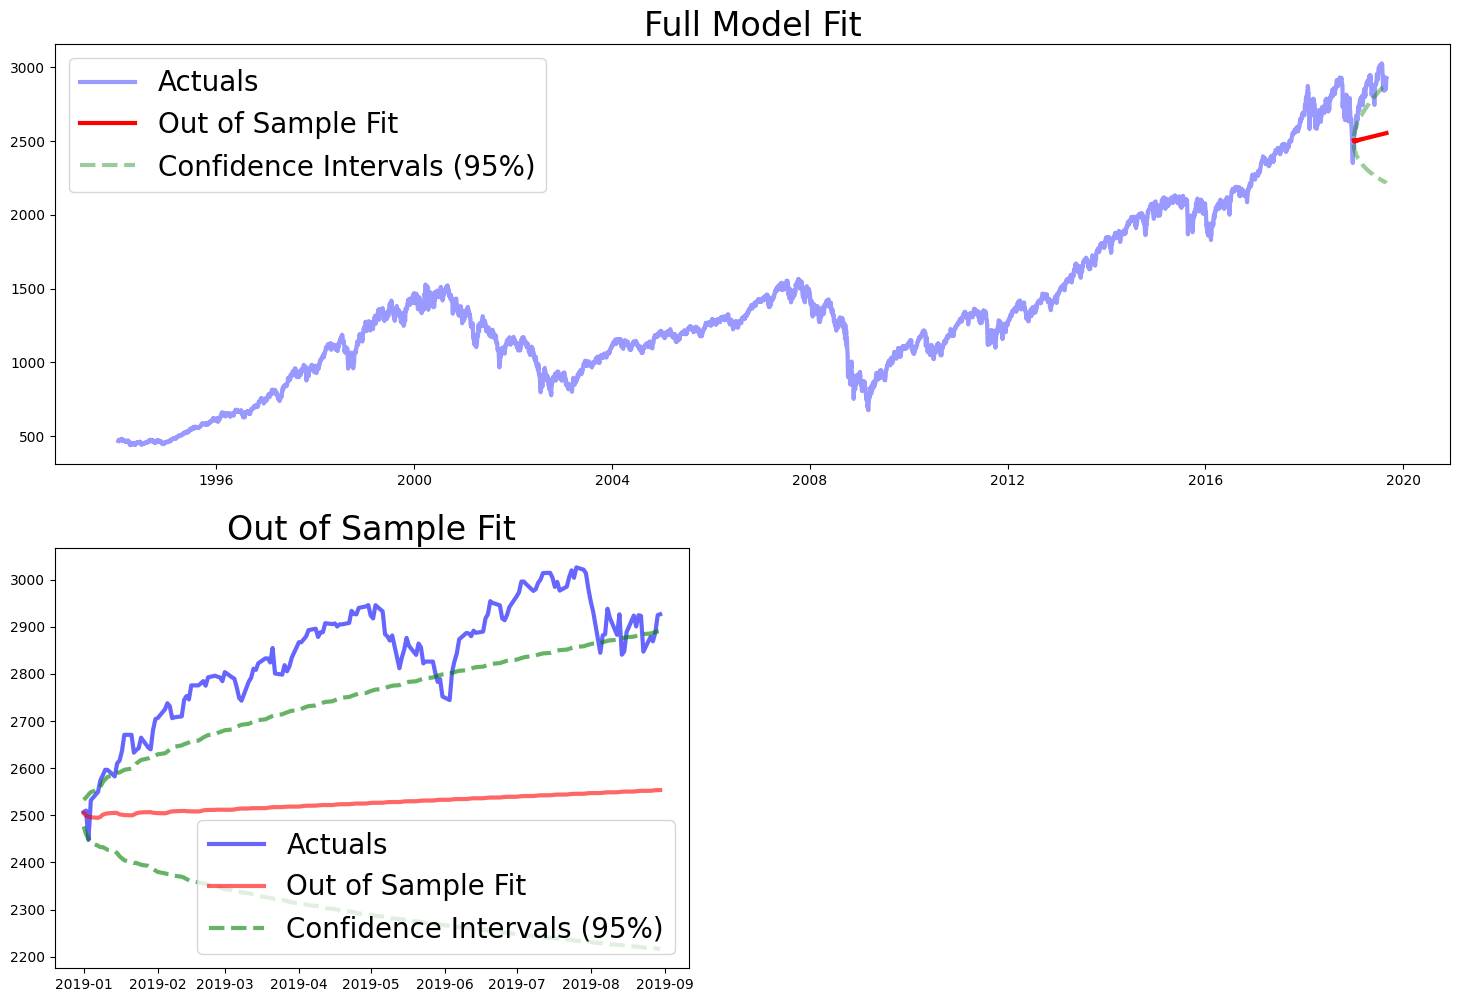

In [ ]:
# Устанавливаем размер графиков для наглядности
plt.rcParams["figure.figsize"] = 18, 12

# Создаем первый график (первый подграфик из двух строк) для полного прогноза модели с доверительными интервалами
plt.subplot(2, 1, 1)

# Строим реальные значения (Actuals) для тестового набора данных
plt.plot(pred_df["spx"], color="blue", label="Actuals", alpha=0.4)

# Строим предсказания модели (Out of Sample Fit) для тестового набора
plt.plot(
    pred_df.loc[test_df.index]["model_preds"],
    color="red",
    linestyle="-",
    label="Out of Sample Fit",
)

# Строим нижнюю границу доверительного интервала (Confidence Intervals) для прогноза
plt.plot(
    pred_df.loc[test_df.index]["model_preds_lower"],
    color="green",
    linestyle="--",
    label="Confidence Intervals (95%)",
    alpha=0.4,
)

# Строим верхнюю границу доверительного интервала (Confidence Intervals) для прогноза
plt.plot(
    pred_df.loc[test_df.index]["model_preds_upper"],
    color="green",
    linestyle="--",
    alpha=0.4,
)

# Добавляем заголовок и легенду
plt.title("Full Model Fit", size=24)
plt.legend()

# Создаем второй график (третий подграфик из четырех) для визуализации прогноза только для тестового набора
plt.subplot(2, 2, 3)

# Строим реальные значения для тестового набора данных
plt.plot(
    pred_df.loc[test_df.index]["spx"], color="blue", label="Actuals", alpha=0.6
)

# Строим предсказания модели (Out of Sample Fit) для тестового набора
plt.plot(
    pred_df.loc[test_df.index]["model_preds"],
    color="red",
    linestyle="-",
    label="Out of Sample Fit",
    alpha=0.6,
)

# Строим нижнюю границу доверительного интервала для прогноза
plt.plot(
    pred_df.loc[test_df.index]["model_preds_lower"],
    color="green",
    linestyle="--",
    label="Confidence Intervals (95%)",
    alpha=0.6,
)

# Строим верхнюю границу доверительного интервала для прогноза
plt.plot(
    pred_df.loc[test_df.index]["model_preds_upper"],
    color="green",
    linestyle="--",
    alpha=0.6,
)

# Добавляем заголовок и легенду
plt.title("Out of Sample Fit", size=24)
plt.legend()

# Отображаем оба графика
plt.show()


In [ ]:
# Устанавливаем библиотеку pmdarima для автоматического выбора модели ARIMA
!pip -q install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.1 MB/s eta 0:00:00


In [ ]:
import pmdarima as pm

# Используем auto_arima для автоматического подбора модели ARIMA
# Параметры:
# - start_p=1, start_q=1: начинаем с порядка AR и MA равного 1
# - max_p=3, max_q=3: максимальный порядок для AR и MA равный 3
# - d=1: дифференцирование первого порядка
# - D=1: сезонное дифференцирование
# - start_P=0: начинаем с порядка сезонной авторегрессии равного 0
# - m=5: длина сезонного цикла (например, 5 периодов)
# - test="adf": используем тест Дики-Фуллера для проверки стационарности
# - error_action="ignore": игнорируем ошибки (если модель не подходит)
# - trace=True: выводим информацию о процессе подбора модели
smodel = pm.auto_arima(
    train_df["spx"],  # Используем столбец "spx" из тренировочного набора данных
    start_p=1,
    d=1,
    start_q=1,
    max_p=3,
    max_q=3,
    D=1,
    start_P=0,
    m=5,
    test="adf",
    error_action="ignore",
    trace=True,
)

# Выводим сводку по выбранной модели
smodel.summary()


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[5]             : AIC=inf, Time=26.75 sec
 ARIMA(0,1,0)(0,1,0)[5]             : AIC=57943.325, Time=1.71 sec
 ARIMA(1,1,0)(1,1,0)[5]             : AIC=55834.625, Time=4.66 sec
 ARIMA(0,1,1)(0,1,1)[5]             : AIC=inf, Time=8.71 sec
 ARIMA(1,1,0)(0,1,0)[5]             : AIC=57939.123, Time=0.44 sec
 ARIMA(1,1,0)(2,1,0)[5]             : AIC=55138.362, Time=4.02 sec
 ARIMA(1,1,0)(2,1,1)[5]             : AIC=inf, Time=18.87 sec
 ARIMA(1,1,0)(1,1,1)[5]             : AIC=inf, Time=11.02 sec
 ARIMA(0,1,0)(2,1,0)[5]             : AIC=55142.946, Time=1.74 sec
 ARIMA(2,1,0)(2,1,0)[5]             : AIC=55124.504, Time=2.65 sec
 ARIMA(2,1,0)(1,1,0)[5]             : AIC=55827.531, Time=1.98 sec
 ARIMA(2,1,0)(2,1,1)[5]             : AIC=inf, Time=26.55 sec
 ARIMA(2,1,0)(1,1,1)[5]             : AIC=inf, Time=17.58 sec
 ARIMA(3,1,0)(2,1,0)[5]             : AIC=55125.927, Time=3.34 sec
 ARIMA(2,1,1)(2,1,0)[5]             : AIC=55141.92

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                 6518
Model:             SARIMAX(2, 1, 0)x(2, 1, 0, 5)   Log Likelihood              -27557.252
Date:                           Sat, 09 Nov 2024   AIC                          55124.504
Time:                                   20:22:01   BIC                          55158.411
Sample:                               01-06-1994   HQIC                         55136.230
                                    - 12-31-2018                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0335      0.008     -4.447      0.000      -0.048      -0.019
ar.L2         -0.0494      0.007     -7.204      0.000      -0.063      -0.036
ar.S.L5       -0.6999      0.007    -99.802      0.000      -0.714      -0.686
ar.S.L10      -0.3228      0.007    -43.233      0.000      -0.337      -0.308
sigma2       277.3268      2.423    114.438      0.000     272.577     282.077
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             11066.86
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               1.98   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Интерполяция и сэмплирование

Иногда можно столкнуться с отсутствием данных, например когда вы обрабатываете показания счётчика потребления горячей и холодной воды, а он по какой-то причине не работал несколько дней. Пропуски могут быть заполнены значениями NaN или нулями.

Взгляните на график ниже: за два дня (конец декабря и начало января) данные отсутствуют (они равны нулю) — из-за этого образуются спады до 0 в районе января.

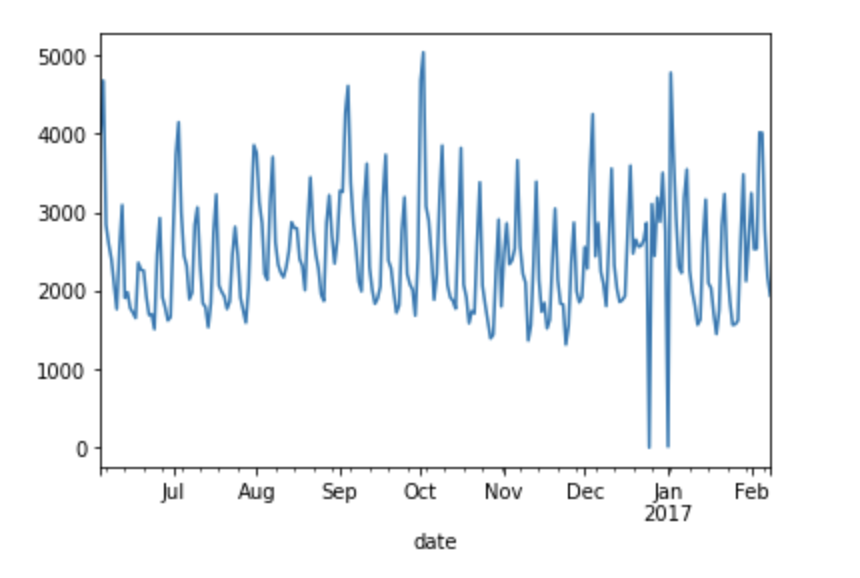

Хотим ли мы, чтобы модель, которая должна предсказывать объём потребления воды, учитывала эти значения, равные нулю? Очевидно, нет. Значит, нам нужно каким-то образом заполнить пропуски, причём заполнение нулями нам не подходит, а заполнение средним — тоже не самая эффективная идея.

А что, если у нас есть показания счётчика по дням, а заказчик хочет получить прогноз по часам? Тогда нам снова нужно как-то заполнить возникающие пропуски для часов.

Знакомьтесь — перед нами проблемы *upsampling* и *downsampling* на временных рядах.

> **Upsampling** — это увеличение частоты выборки (повышение частоты дискретизации), например с минут до секунд. Также upsampling применяют для заполнения пропусков неизвестных значений. Для этой цели мы будем использовать **интерполяцию**.

> **Downsampling** — это уменьшение частоты выборки, например с дней до месяцев.

### Downsampling

По своей сути, **downsampling** — это перегруппировка. Мы можем сгруппировать значения, полученные по дням, в значения, полученные за месяц, путём использования метода `groupby()`. Однако существует ещё один встроенный в DataFrame метод с чуть более широким функционалом — `resample()`. Этот метод позволяет делать нестандартные группировки, такие как «за три дня» или «за каждые шесть секунд», то есть вы можете выбрать свой интервал группировки и получить результат, написав одну строку кода. Вызывать метод `resample` необходимо у датафрейма, в качестве индекса у которого используются даты в формате `datetime`. Например, если наш временной ряд с показаниями счетчика по потреблению воды изначально сгруппирован по дням, применив к нему `resample`, можно получить:

* общие количества за каждые три месяца (`.resample("3M").sum()`)

In [ ]:
data.resample("3M").sum()

,spx
Date,
1994-01-31,8532.970001
1994-04-30,29490.340027
1994-07-31,29406.589996
1994-10-31,30694.789978
1995-01-31,30379.519958
...,...
2018-10-31,187825.589600
2019-01-31,173600.540283
2019-04-30,177886.509277


* средние значения за каждые 20 часов (`.resample("20h").mean()`)

In [ ]:
data.resample("20h").mean()

,spx
Date,
1994-01-06 00:00:00,467.119995
1994-01-06 20:00:00,469.899994
1994-01-07 16:00:00,NaN
1994-01-08 12:00:00,NaN
1994-01-09 08:00:00,475.269989
...,...
2019-08-26 08:00:00,2869.159912
2019-08-27 04:00:00,NaN
2019-08-28 00:00:00,2887.939941


* максимальные значения за каждый квартал (`.resample("Q").max()`)

In [ ]:
data.resample("Q").max()

,spx
Date,
1994-03-31,482.000000
1994-06-30,462.369995
1994-09-30,476.070007
1994-12-31,473.769989
1995-03-31,503.899994
...,...
2018-09-30,2930.750000
2018-12-31,2925.510010
2019-03-31,2854.879883


Дальше уже можно работать над построением модели.

Правила группировки (Q, H, M и др.) — это сокращения, используемые в работе с типом данных `Timestamp`. Полный перечень правил группировки можно найти в документации (таблица Date Offset).

Теперь пора переходить к `upsampling`. Но прежде рассмотрим понятие, которое мы уже упоминали выше, — **«интерполяция»**.

#### Интерполяция

> Говоря простым языком, **интерполяция** — это нахождение некоторых промежуточных значений по функции, описывающей поведение данных. То есть если мы найдём такую функцию, значения которой будут совпадать с уже известными нам значениями, то можно предположить, что она поможет верно или приблизительно восстановить для нас неизвестные значения.

Существуют несколько способов нахождения этой функции, и интерполяция может быть выполнена с помощью:

* линейной функции,
* многочлена Лагранжа,
* интерполяционной формулы Ньютона,
* семейства сплайн-функций.

### Upsampling

Для реализации *upsampling* на практике мы будем использовать уже известный нам метод `resample`, чтобы декомпозировать данные, например от дня к часам, а затем воспользуемся встроенным методом `interpolate()`, который принимает в качестве аргумента указание метода интерполяции: `'linear'`, `'nearest'`, `'spline'`, `'barycentric'`, `'polynomial'` и другие. То есть сначала мы применяем к данным `resample()` с параметром h (час), а затем вместо агрегирующей функции `sum/mean` и др. применяем `interpolate('linear')`, чтобы выполнить линейную интерполяцию.

Пример результата выполнения функции — ниже.

In [ ]:
data.resample("h").interpolate(method='linear')

,spx
Date,
1994-01-06 00:00:00,467.119995
1994-01-06 01:00:00,467.235828
1994-01-06 02:00:00,467.351662
1994-01-06 03:00:00,467.467495
1994-01-06 04:00:00,467.583328
...,...
2019-08-29 20:00:00,2926.146647
2019-08-29 21:00:00,2926.224976
2019-08-29 22:00:00,2926.303304


## Практика

Продолжим решать задачу с фондовыми индексами, но в разрезе использования интерполяции.

Мы уже знакомы с данными и помним, что мы имеем временной ряд, данные в который поступали по будням, то есть 5 дней в неделю.

Попробуем сделать прогноз по недельным значениям. Для этого необходимо сделать декомпозицию по неделям.

In [ ]:
# Выводим размерность набора данных (количество строк и столбцов) для информации
print(data.shape)

# Отображаем первые строки данных, которые находятся в диапазоне дат с 6 января 2005 по 10 февраля 2005.
# Условие фильтрации выбирает строки, где индекс даты больше "2005-01-06" и меньше "2005-02-10".
data[(data.index > "2005-01-06") & (data.index < "2005-02-10")].head()


(6692, 1)


,spx
Date,
2005-01-07,1186.189941
2005-01-10,1190.250000
2005-01-11,1182.989990
2005-01-12,1187.699951
2005-01-13,1177.449951


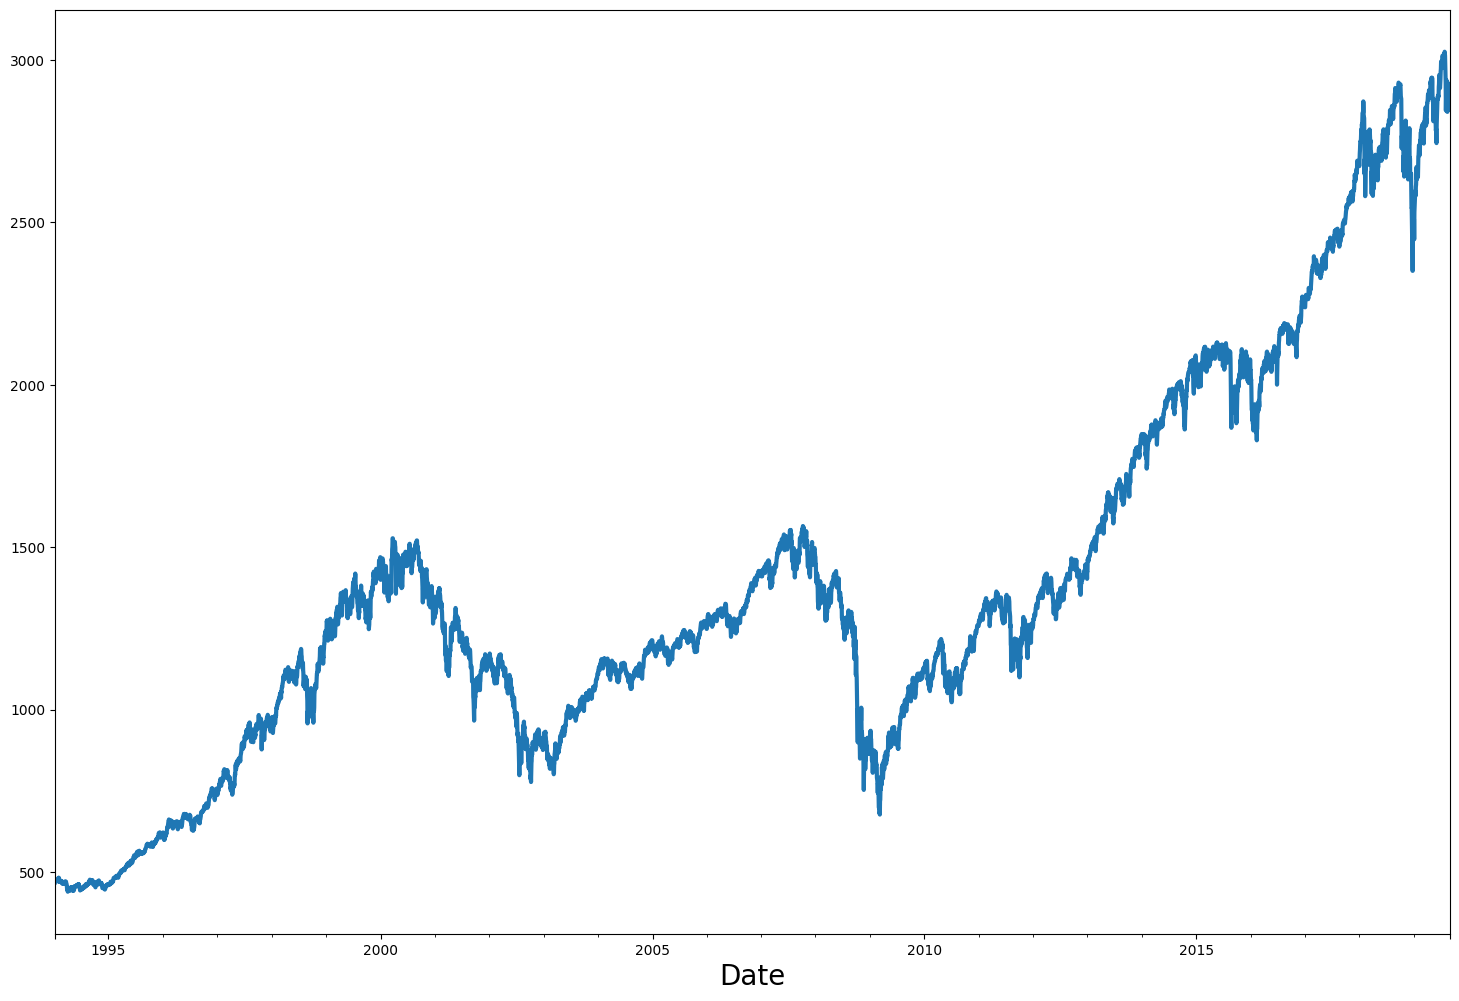

In [ ]:
# Строим график временного ряда для столбца "spx" в наборе данных "data"
data.spx.plot()

# Отображаем график
plt.show()


(1339, 1)


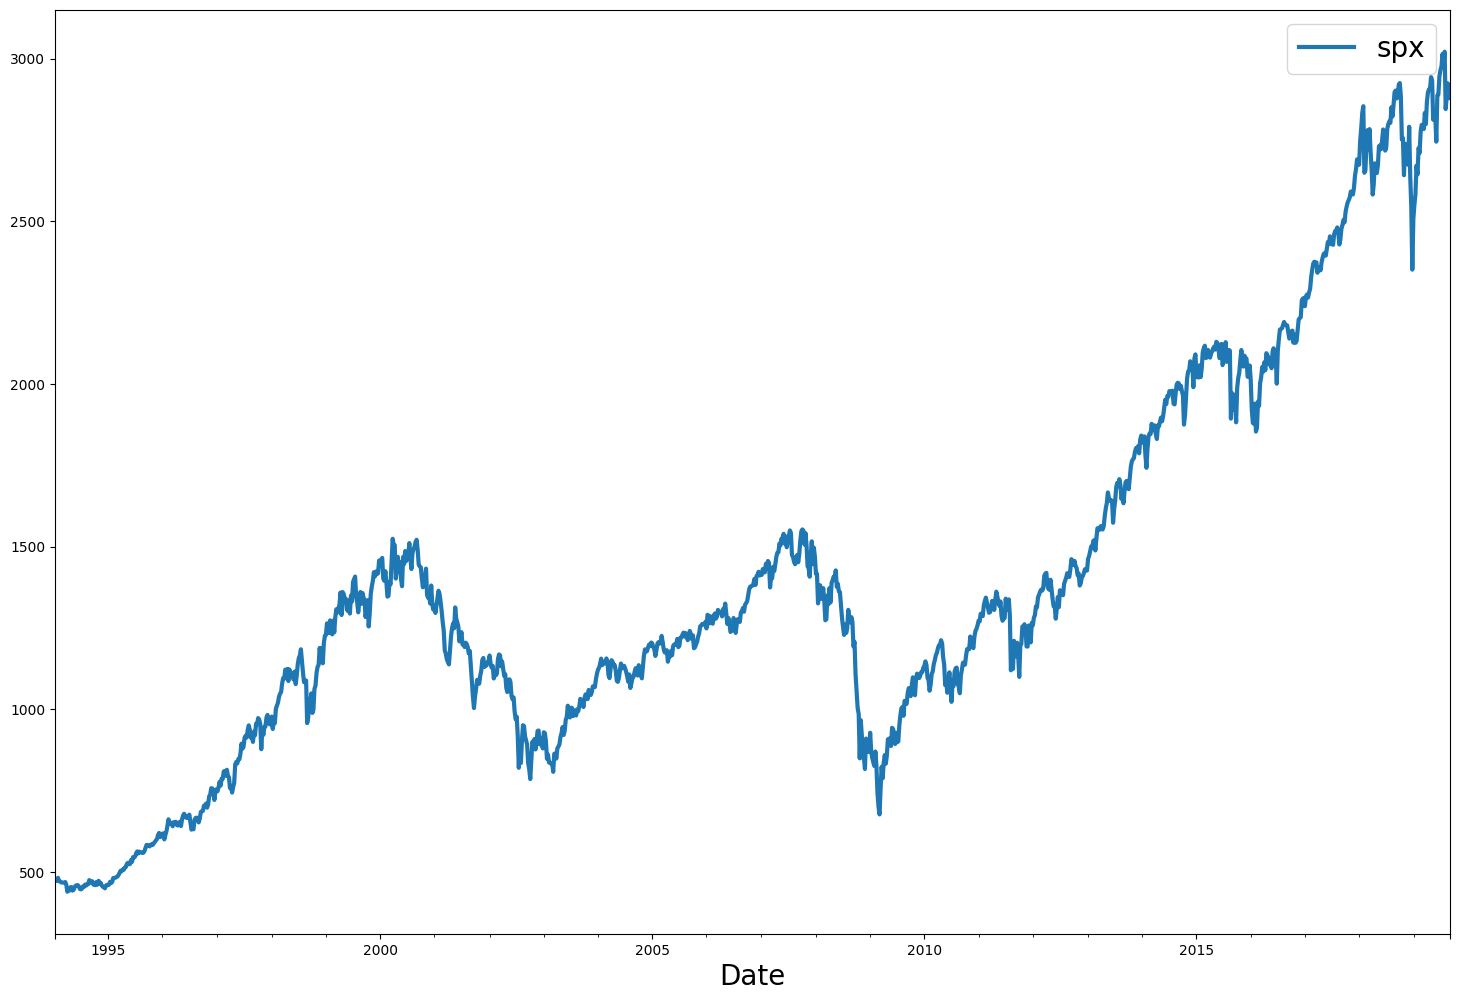

In [ ]:
# Создаем новый DataFrame с интерполированными значениями временного ряда "spx"
# Используем resample для агрегирования данных с недельной частотой по понедельникам ("w-MON")
# и применяем интерполяцию для заполнения пропусков в данных

interpolated_data = pd.DataFrame(
    data.spx.resample("w-MON").interpolate(), columns=["spx"]
)

# Выводим размерность нового DataFrame для информации
print(interpolated_data.shape)

# Строим график интерполированного временного ряда
interpolated_data.plot()

# Отображаем график
plt.show()


In [ ]:
# Отображаем первые несколько строк интерполированного DataFrame для проверки результата
interpolated_data.head()


,spx
Date,
1994-01-10,475.269989
1994-01-17,473.299988
1994-01-24,471.970001
1994-01-31,481.609985
1994-02-07,471.760010


In [ ]:
# Разделяем интерполированные данные на обучающую и тестовую выборки
# Обучающая выборка: до 31 декабря 2018 года включительно
# Тестовая выборка: начиная с 1 января 2019 года

train_df = interpolated_data.loc[:"2018-12-31"]
test_df = interpolated_data.loc["2019-01-01":]

# Выводим размерности обучающей и тестовой выборок
train_df.shape, test_df.shape


((1304, 1), (35, 1))

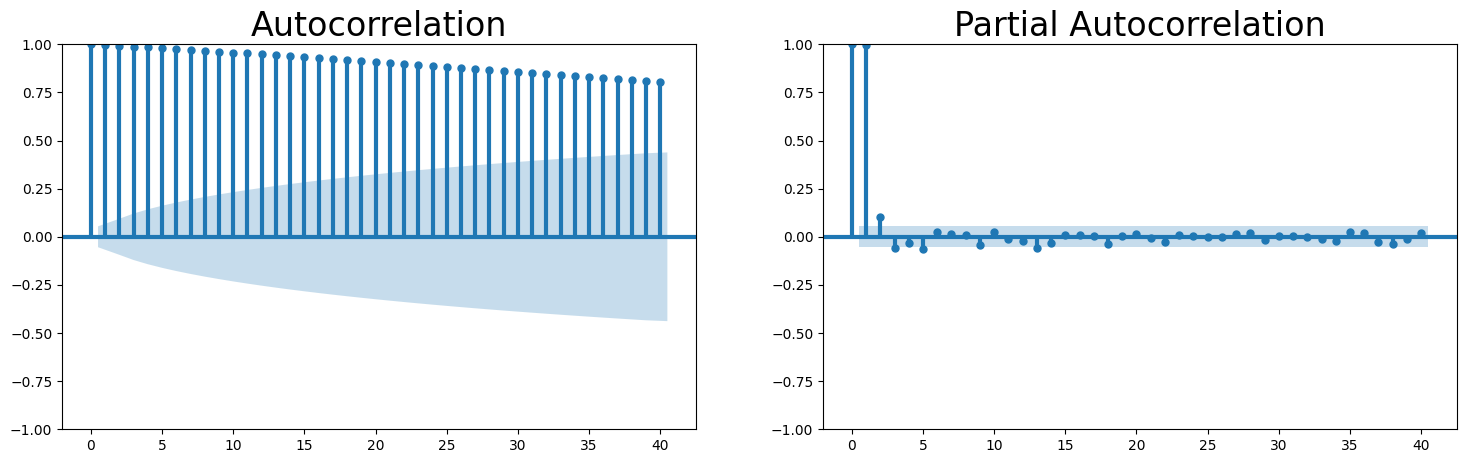

(-0.2607657143116782,
 0.9308801996019748,
 10,
 1293,
 {'1%': -3.4354175403897727,
  '5%': -2.8637778952086848,
  '10%': -2.5679614713589562},
 12512.497637173248)

In [ ]:
# Строим графики автокорреляционной и частной автокорреляционной функций для обучающей выборки
# Удаляем возможные пропуски в данных перед передачей в функцию
plot_acf_pacf(train_df["spx"].dropna())

# Применяем тест Дики-Фуллера для проверки стационарности ряда в обучающей выборке
adfuller(train_df["spx"].dropna())

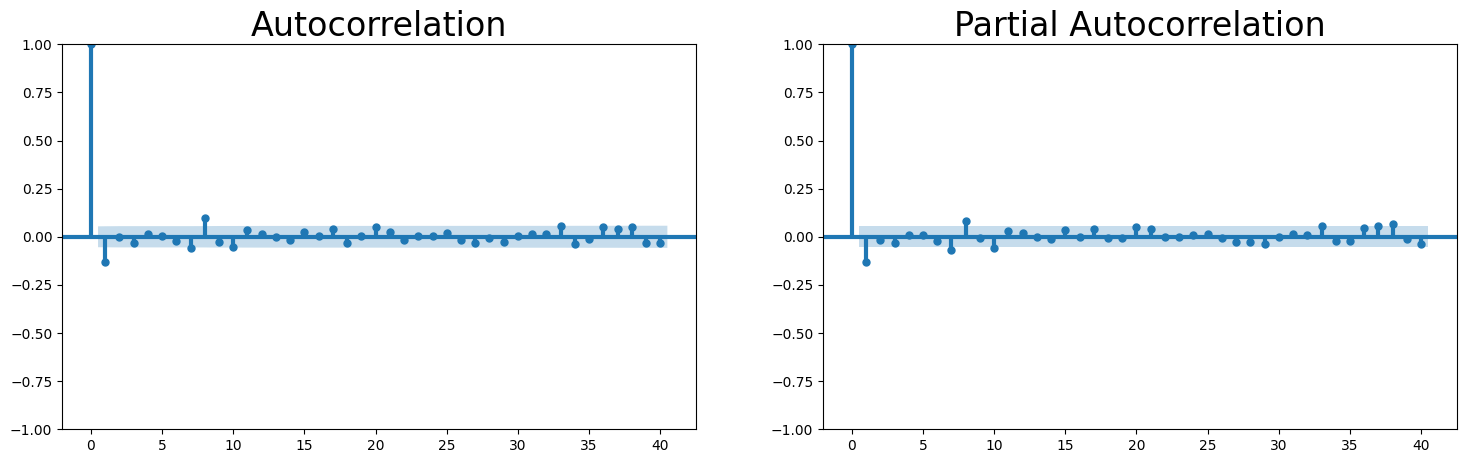

(-11.946377875600588,
 4.420358877552662e-22,
 9,
 1293,
 {'1%': -3.4354175403897727,
  '5%': -2.8637778952086848,
  '10%': -2.5679614713589562},
 12501.713967337682)

In [ ]:
plot_acf_pacf(train_df["spx"].diff().dropna())
adfuller(train_df["spx"].diff().dropna())

In [ ]:
# Импортируем библиотеку для работы с моделью ARIMA и визуализацией
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot as plt

# Создаем и обучаем модель ARIMA с параметрами (p=1, d=1, q=1)
# Параметры:
# - p=1: порядок авторегрессии
# - d=1: порядок дифференцирования для стационарности
# - q=1: порядок модели скользящего среднего
arima_model = ARIMA(train_df["spx"].dropna(), order=(1, 1, 1))
arima_model_fit = arima_model.fit()

# Выводим сводку модели с оценками параметров и статистическими характеристиками
arima_model_fit.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    spx   No. Observations:                 1304
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -6359.035
Date:                Sat, 09 Nov 2024   AIC                          12724.070
Time:                        20:41:08   BIC                          12739.587
Sample:                    01-10-1994   HQIC                         12729.891
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0215      0.137      0.157      0.875      -0.247       0.290
ma.L1         -0.1545      0.132     -1.173      0.241      -0.413       0.104
sigma2      1015.0734     20.021     50.701      0.000     975.833    1054.314
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              2373.55
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               2.31   Skew:                            -1.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# Создаем DataFrame для хранения предсказаний модели ARIMA и реальных значений
pred_df = pd.DataFrame(index=interpolated_data.index)

# Добавляем в DataFrame предсказанные моделью значения на период тестовой выборки
pred_df["model_preds"] = arima_model_fit.predict(
    start=test_df.index[0], end=test_df.index[-1]
)

# Добавляем реальные значения временного ряда "spx" для сравнения с предсказаниями
pred_df["spx"] = data["spx"]

# Получаем прогноз на длину тестовой выборки с доверительными интервалами 95%
forecast = arima_model_fit.get_forecast(len(test_df.index))
forecast_df = forecast.conf_int(alpha=0.05)  # Уровень доверия 95%

# Добавляем нижние и верхние границы доверительных интервалов в DataFrame для визуализации
pred_df.at[test_df.index, "model_preds_lower"] = forecast_df["lower spx"]
pred_df.at[test_df.index, "model_preds_upper"] = forecast_df["upper spx"]


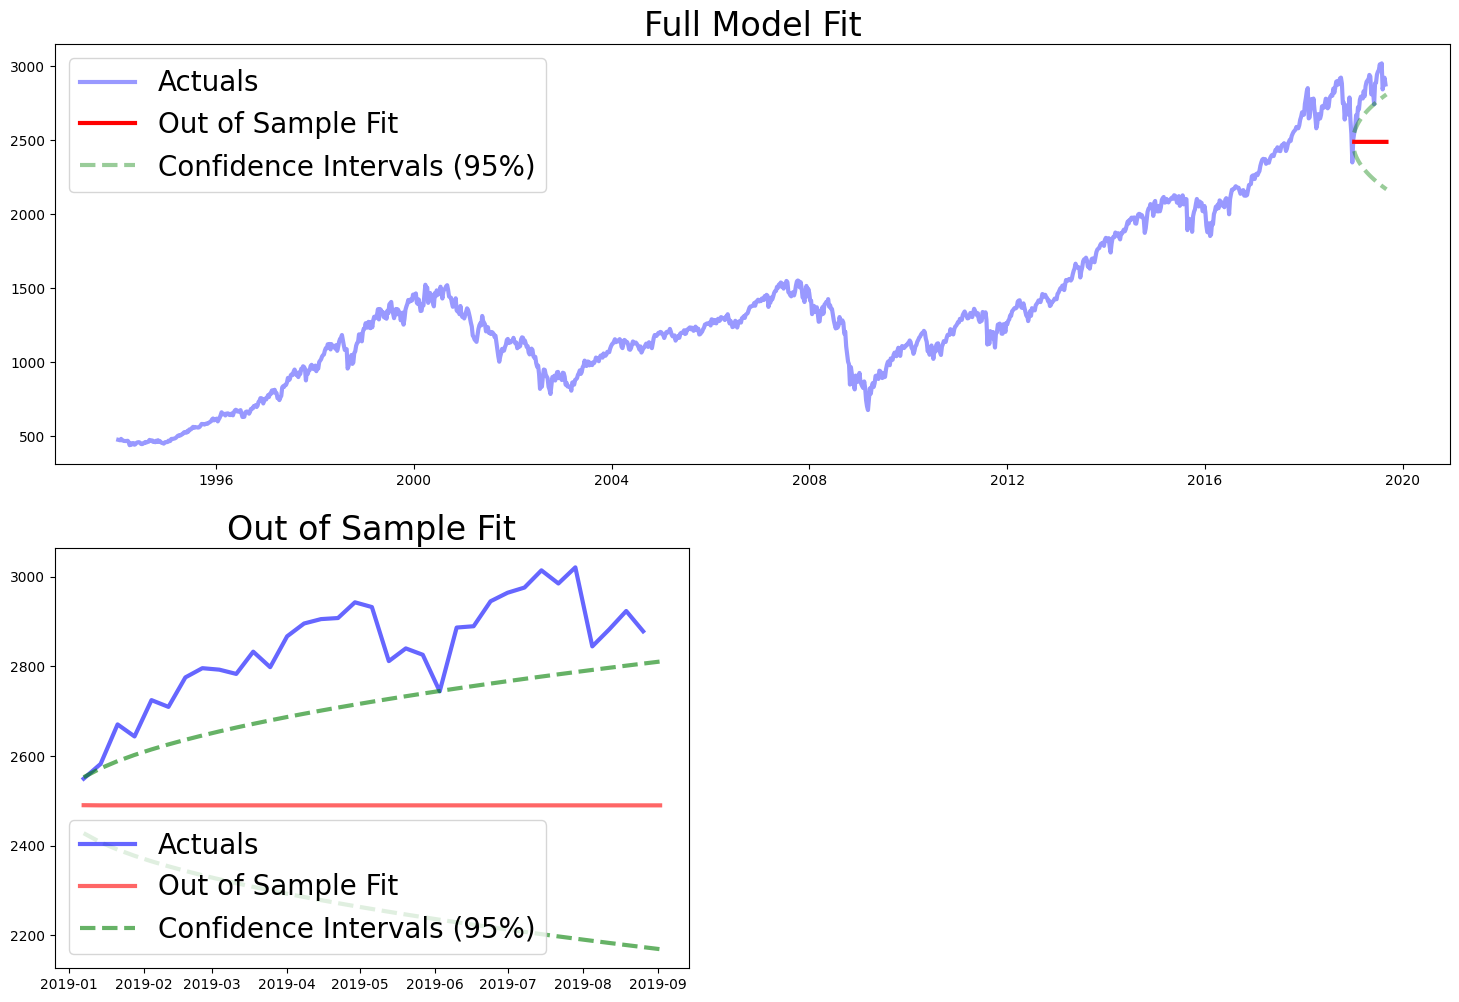

In [ ]:
# Настраиваем размер графика для удобства визуализации
plt.rcParams["figure.figsize"] = 18, 12

# Построение первого графика — полное совпадение модели с фактическими данными
plt.subplot(2, 1, 1)
plt.plot(pred_df["spx"], color="blue", label="Actuals", alpha=0.4)  # Фактические значения

# Построение предсказанных значений на тестовой выборке
plt.plot(
    pred_df.loc[test_df.index]["model_preds"],
    color="red",
    linestyle="-",
    label="Out of Sample Fit",
)

# Построение доверительных интервалов 95% для предсказанных значений
plt.plot(
    pred_df.loc[test_df.index]["model_preds_lower"],
    color="green",
    linestyle="--",
    label="Confidence Intervals (95%)",
    alpha=0.4,
)

plt.plot(
    pred_df.loc[test_df.index]["model_preds_upper"],
    color="green",
    linestyle="--",
    alpha=0.4,
)

# Устанавливаем заголовок и легенду для первого графика
plt.title("Full Model Fit", size=24)
plt.legend()

# Построение второго графика — более детальный вид "Out of Sample Fit"
plt.subplot(2, 2, 3)

# Фактические значения на тестовой выборке
plt.plot(
    pred_df.loc[test_df.index]["spx"], color="blue", label="Actuals", alpha=0.6
)

# Предсказанные значения на тестовой выборке
plt.plot(
    pred_df.loc[test_df.index]["model_preds"],
    color="red",
    linestyle="-",
    label="Out of Sample Fit",
    alpha=0.6,
)

# Доверительные интервалы 95% для предсказанных значений
plt.plot(
    pred_df.loc[test_df.index]["model_preds_lower"],
    color="green",
    linestyle="--",
    label="Confidence Intervals (95%)",
    alpha=0.6,
)

plt.plot(
    pred_df.loc[test_df.index]["model_preds_upper"],
    color="green",
    linestyle="--",
    alpha=0.6,
)

# Устанавливаем заголовок и легенду для второго графика
plt.title("Out of Sample Fit", size=24)
plt.legend()

# Отображаем оба графика
plt.show()


## Модели прогнозирования гетероскедастичности

**Гетероскедастичность** — понятие, используемое в прикладной статистике (чаще всего — в эконометрике), означающее неоднородность наблюдений, выражающуюся в неодинаковой (непостоянной) дисперсии случайной ошибки регрессионной (эконометрической) модели.

> У временных рядов есть интересная и нередко встречающаяся особенность. Обратите внимание на график квартального дохода компании Wal-Mart. Видно, что присутствует тренд. Но какую ещё особенность вы видите?

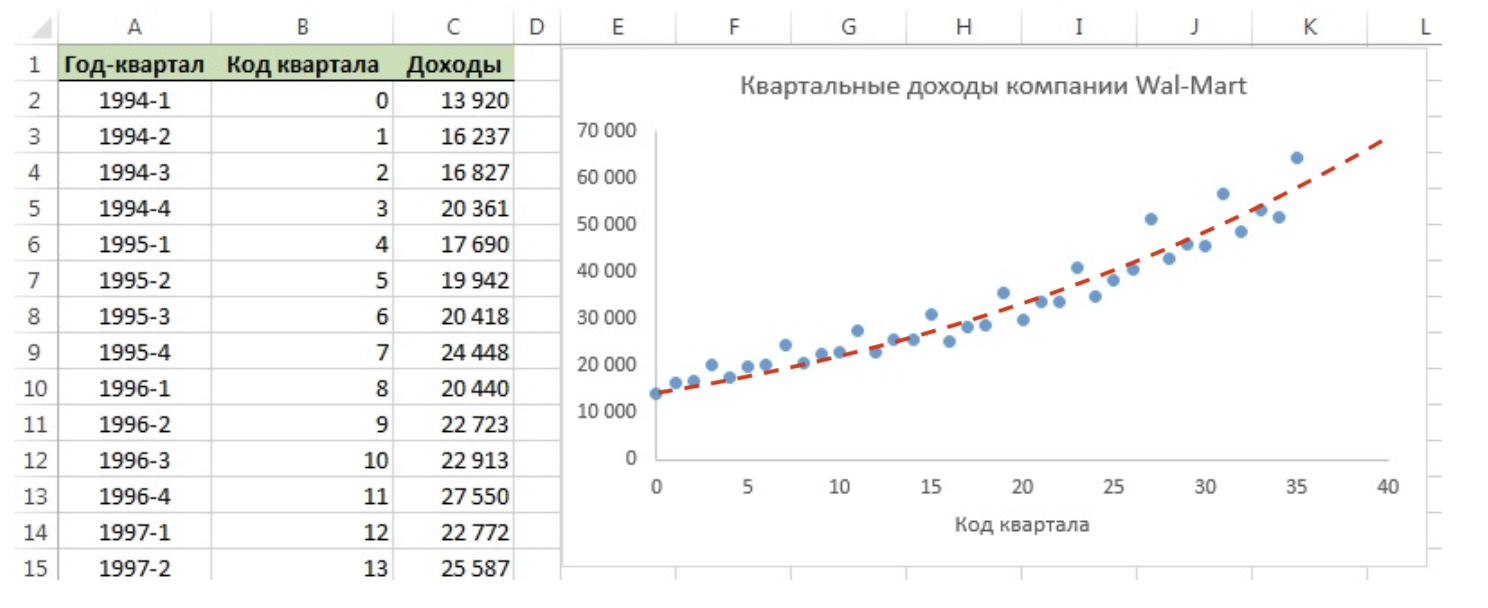

Прежде чем перейти к обсуждению, вспомним, что такое дисперсия.

> **Дисперсия** — это статистический показатель, показывающий меру разброса данных вокруг среднего значения.

Если мы проведём на графике усреднённую прямую (красный пунктир), будет заметно, что ближе к 1997 году точки имеют больший разброс, чем в начале, то есть дисперсия данных изменчива во времени.

Подобная неоднородность наблюдений, выражающаяся в неодинаковой дисперсии, называется **гетероскедастичностью**.

Такой характер дисперсии можно часто встретить во временных рядах из финансовой сферы, поскольку они более подвержены гетероскедастичности.

Отсутствие гетероскедастичности называется **гомоскедастичностью**.

Сравните графики временных рядов ниже:

* Гомоскедастичный временной ряд:

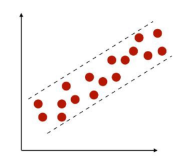

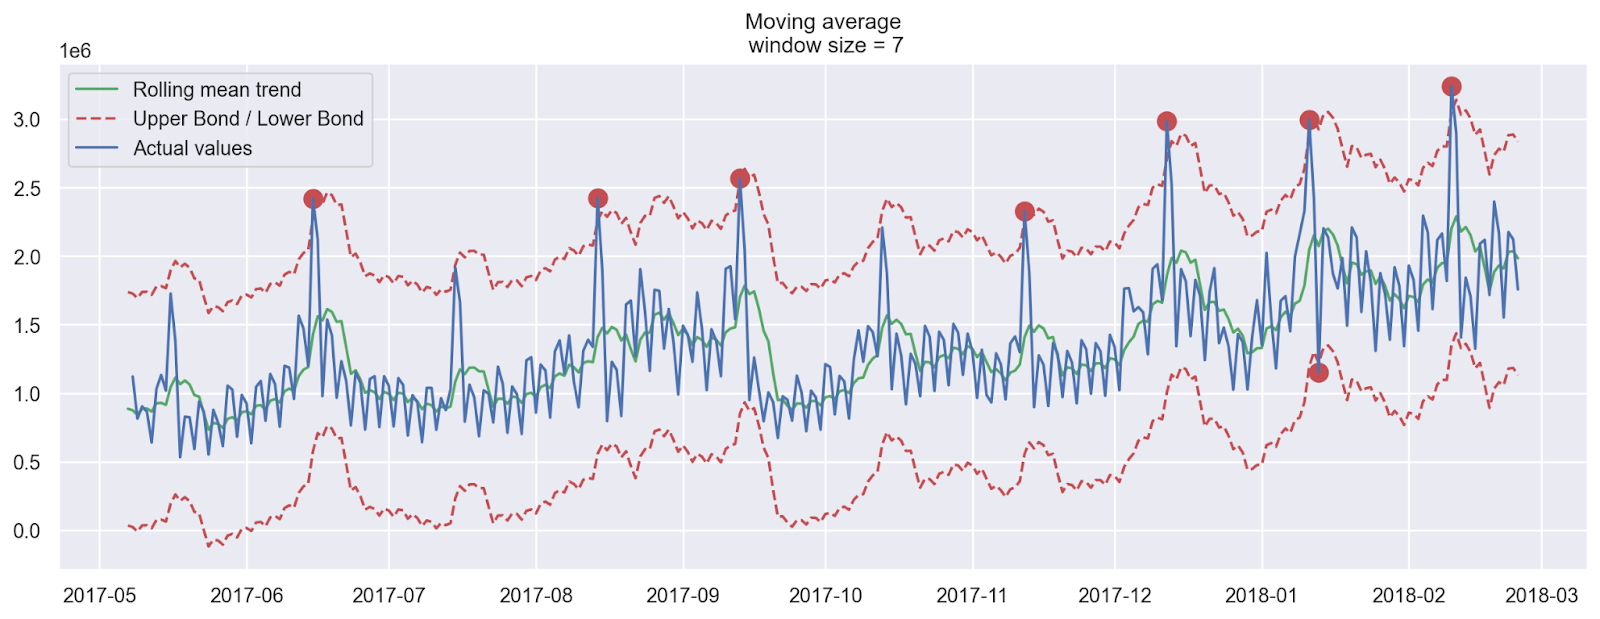

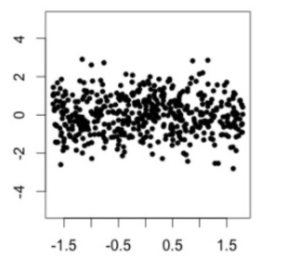

* Гетероскедастичный временной ряд:

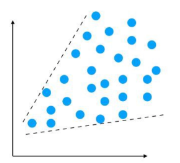

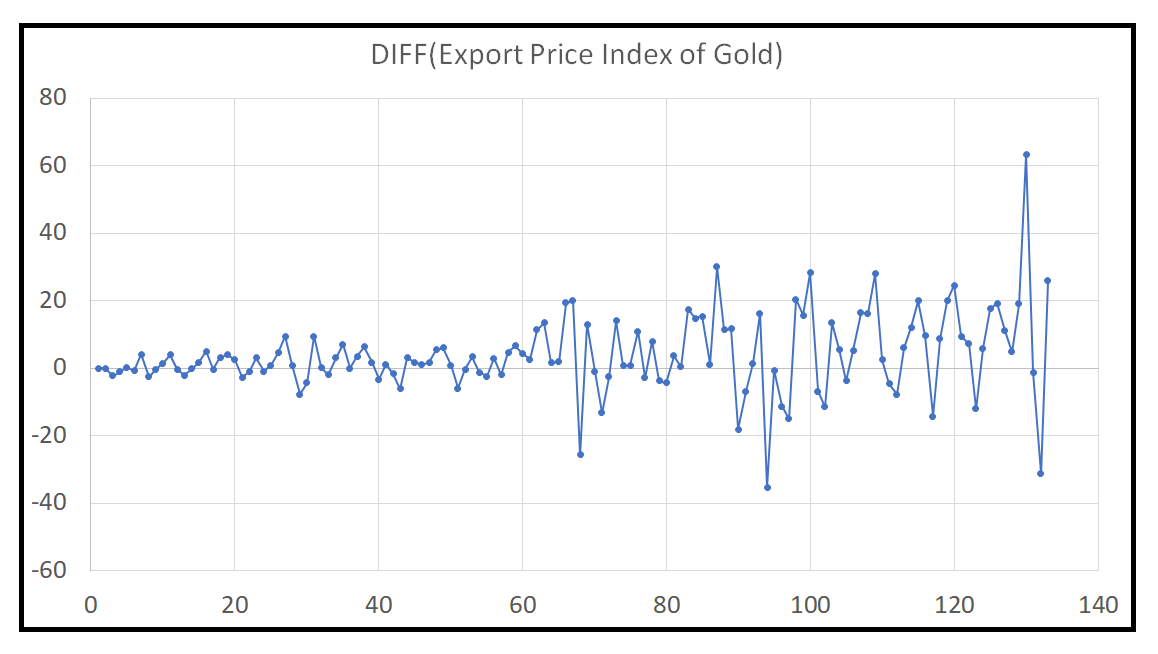

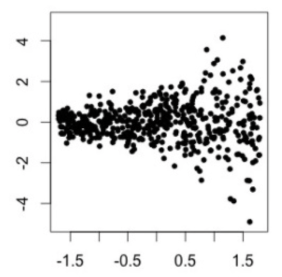

Изученные нами модели помогают учесть тренд и сезонность. Но что насчёт дисперсии? Обычно, если временной ряд обладает гетероскедастичностью, такие модели не способны уловить изменение дисперсии во времени, и их предсказания выглядят примерно так:

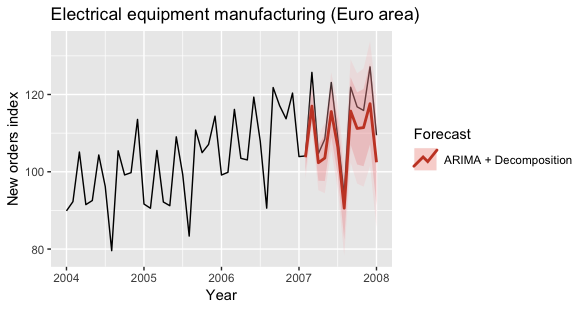

Видно, что в предсказании мы не учли разброс — прогноз хочется «вытянуть» вверх, таким образом увеличивая дисперсию. Такая проблема часто возникает в волатильных временных рядах. Понятие волатильности также относится к финансовым временным рядам и является одним из самых важных финансовых показателей и понятий в управлении финансовыми рисками.

**Волатильность** представляет собой меру риска использования финансового инструмента за заданный промежуток времени. Иными словами, волатильность показывает меру изменчивости и часто измеряется в процентах или долях. Предсказание волатильности, например, позволяет инвесторам определить риск приобретения финансового инструмента.

Для таких данных с непостоянной дисперсией был разработан ещё один класс моделей — семейство моделей авторегрессионной условной гетероскедастичности, или **ARCH (Autoregressive Conditional Heteroscedastic Model)**.

### ARCH И GARCH

Давайте сначала разберёмся, как устроена модель ARCH, а затем поговорим о том, как правильно её применять.

Ниже представлен график ошибок предсказания некоторого временного ряда. Что с ним не так?

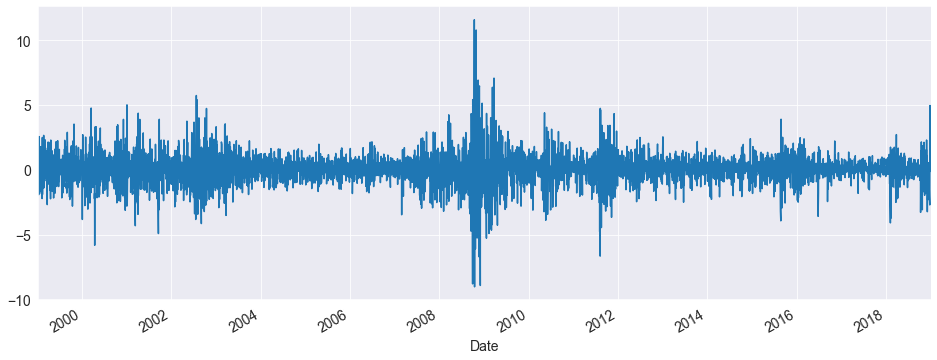

Если на графике выше с математическим ожиданием всё в порядке (среднее значение в нуле), то к дисперсии есть вопросы, так как видно, что она различна на разных промежутках (разброс в разные годы отличен).

Модели семейства ARMA способны предсказывать тренд и сезонность, но, к сожалению, не изменчивость дисперсии.

Модель ARCH была разработана лауреатом Нобелевской премии по экономике Робертом Энглом в 1982 г. для решения подобных проблем. В ней используется зависимая от времени условная дисперсия, которая выражается через квадрат предыдущих значений.

Чуть позднее другой учёный, Тим Боллерслерв, предложил обобщённую концепцию модели ARCH — **GARCH (Generalized Autoregressive Conditional Heteroscedastic Model)**. Модель предполагала, что на изменчивость дисперсии влияют не только предыдущие изменения показателей, но и предыдущие оценки дисперсии (значение дисперсии).

ARCH и GARCH — наиболее популярные модели, используемые при прогнозе волатильности. Существуют и их модернизации, такие как A-GARCH, E-GARCH и многие другие.

#### Когда применять ARCH и GARCH?

* Когда ряд похож на белый шум, но при этом в нём присутствует гетероскедастичность.

 Чтобы определить, является ли ряд гетероскедастичным (с меняющейся дисперсией), можно отобразить его квадраты на графике и понаблюдать за поведением дисперсии.

* Когда после применения AR-модели остатки (ошибки модели) тоже являются гетероскедастичными. В этом случае вы также можете прогнозировать дисперсию ошибок и использовать её в итоговом предсказании. Для этого необходимо суммировать результаты AR-модели с результатами ARCH.

Давайте дополним нашу схему выбора модели:

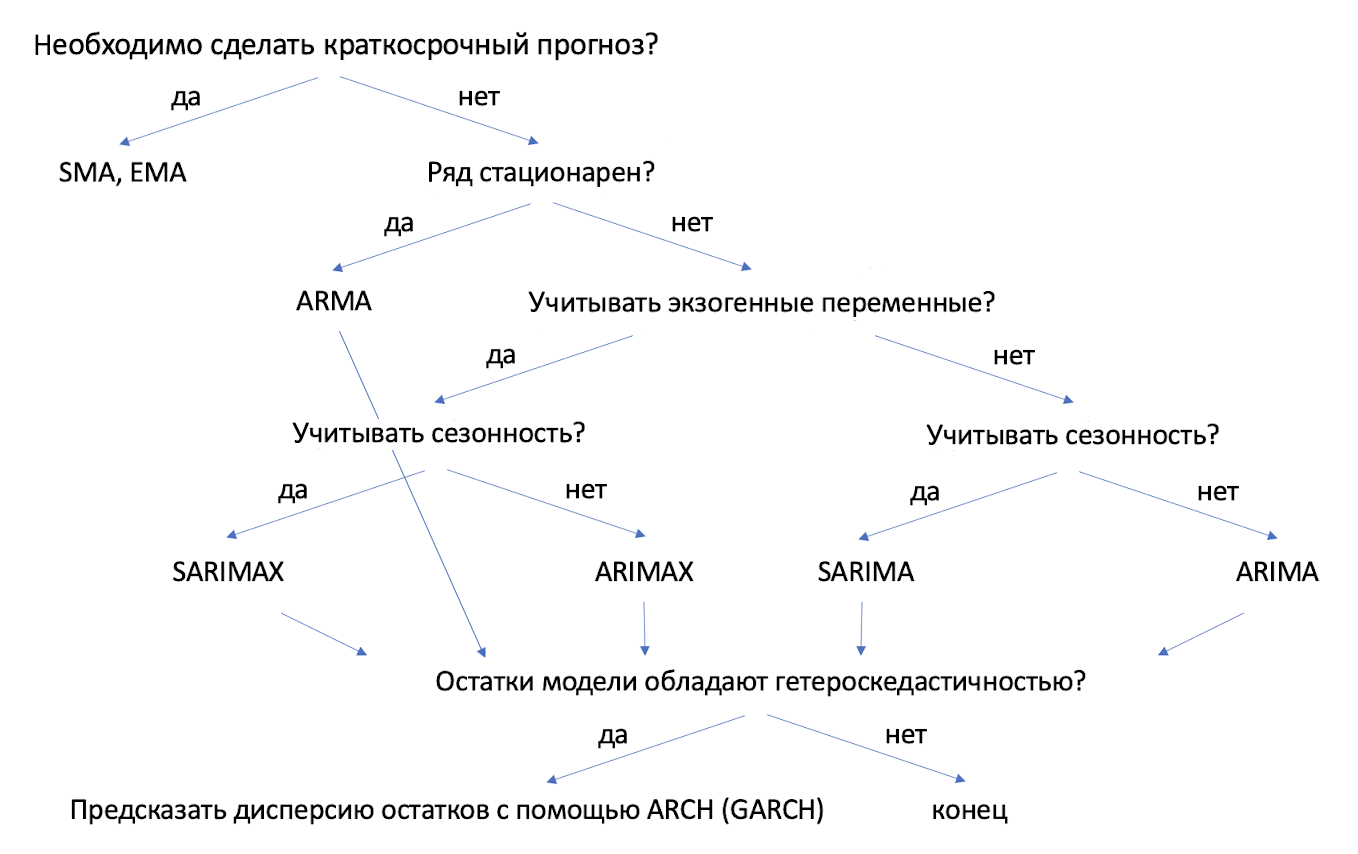

## Валидация временных рядов

Наиболее важным отличием работы с временными рядами от работы с другими данными является то, что к временным рядам нельзя применять обычный подход разбиения на тренировочную и тестовую выборки, тем более делая это случайным образом.

Таким образом, метод `train_test_split` не подходит, так как он разбивает данные случайным образом. В результате нарушается временная связь между данными ряда.

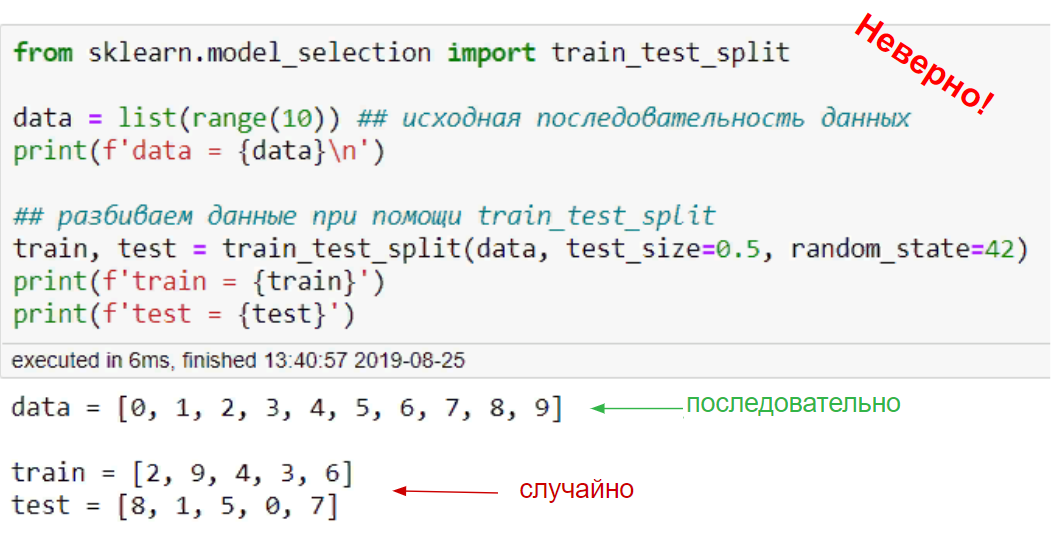

Для данных временного ряда разбиение на тренировочный и тестовый сеты нужно выполнять последовательно, иначе в алгоритм просочится информация из будущего, на которой он и обучается.

Последовательное разбиение может выглядеть так (train - синий, test - зеленый):

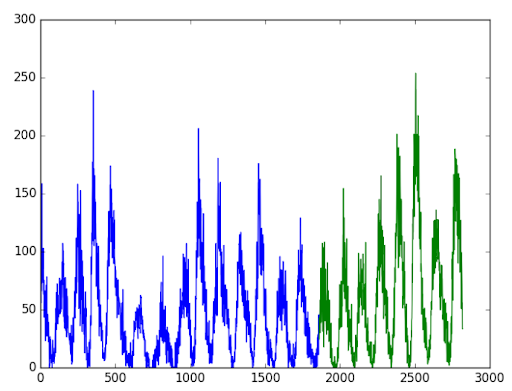

То есть в случае с данными на графике выше правильно будет разбить их как `train = [0,1,2,3,4,5]` и `test = [6,7,8,9]`. Соотношение объёма выборок, конечно, может быть другим, но главное — выборки должны идти последовательно.

### Аналог кросс-валидации для временных рядов

Если использовать обычную кросс-валидацию, информация из будущего снова просочится в алгоритм. Поэтому вместо кросс-валидации используются:

* walk forward validation;

* множественное разбиение.

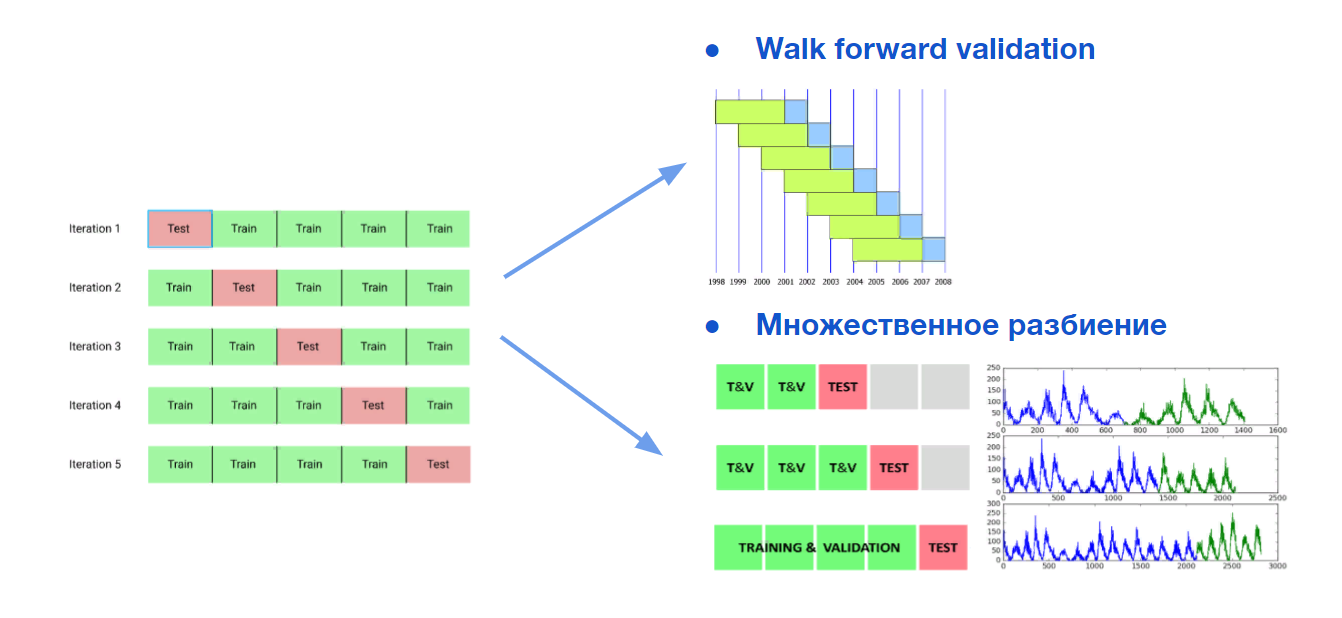

Обратите внимание на изображения выше. В обоих случаях мы также соблюдаем последовательность в разбиении — сравните с обычной кросс-валидацией (слева). Оба разбиения действуют по схожему принципу — делят выборки упорядоченно, чтобы подвыборка test всегда выбиралась после подвыборок train. Отличием будет то, что в walk forward validation размер обучающих выборок во всех фолдах (разбиениях) будет одинаковым, а во множественном разбиении в каждом новом фолде данные обучающей выборки накапливаются.

## Практика



### Волатильность

 **Volatility** at time **t**  

$Vol(t) = |\frac{Price(t) - Price(t-1)}{Price(t-1)} * 100|$

In [ ]:
# Вычисляем волатильность SPX в процентах на основе процентного изменения
# Волатильность рассчитывается как абсолютное значение процентного изменения цены SPX по дням

# Альтернативный способ: data["spx_vol"] = (data.spx - data.spx.shift(1))/data.spx.shift(1)
# Здесь используется метод pct_change(1), который также считает процентное изменение за один шаг
data["spx_vol"] = data.spx.pct_change(1).mul(100).abs()

# Выводим первые пять значений нового столбца "spx_vol", чтобы проверить результат
data["spx_vol"].head()


,spx_vol
Date,
1994-01-06,NaN
1994-01-07,0.595136
1994-01-10,1.142795
1994-01-11,0.239860
1994-01-12,0.008438


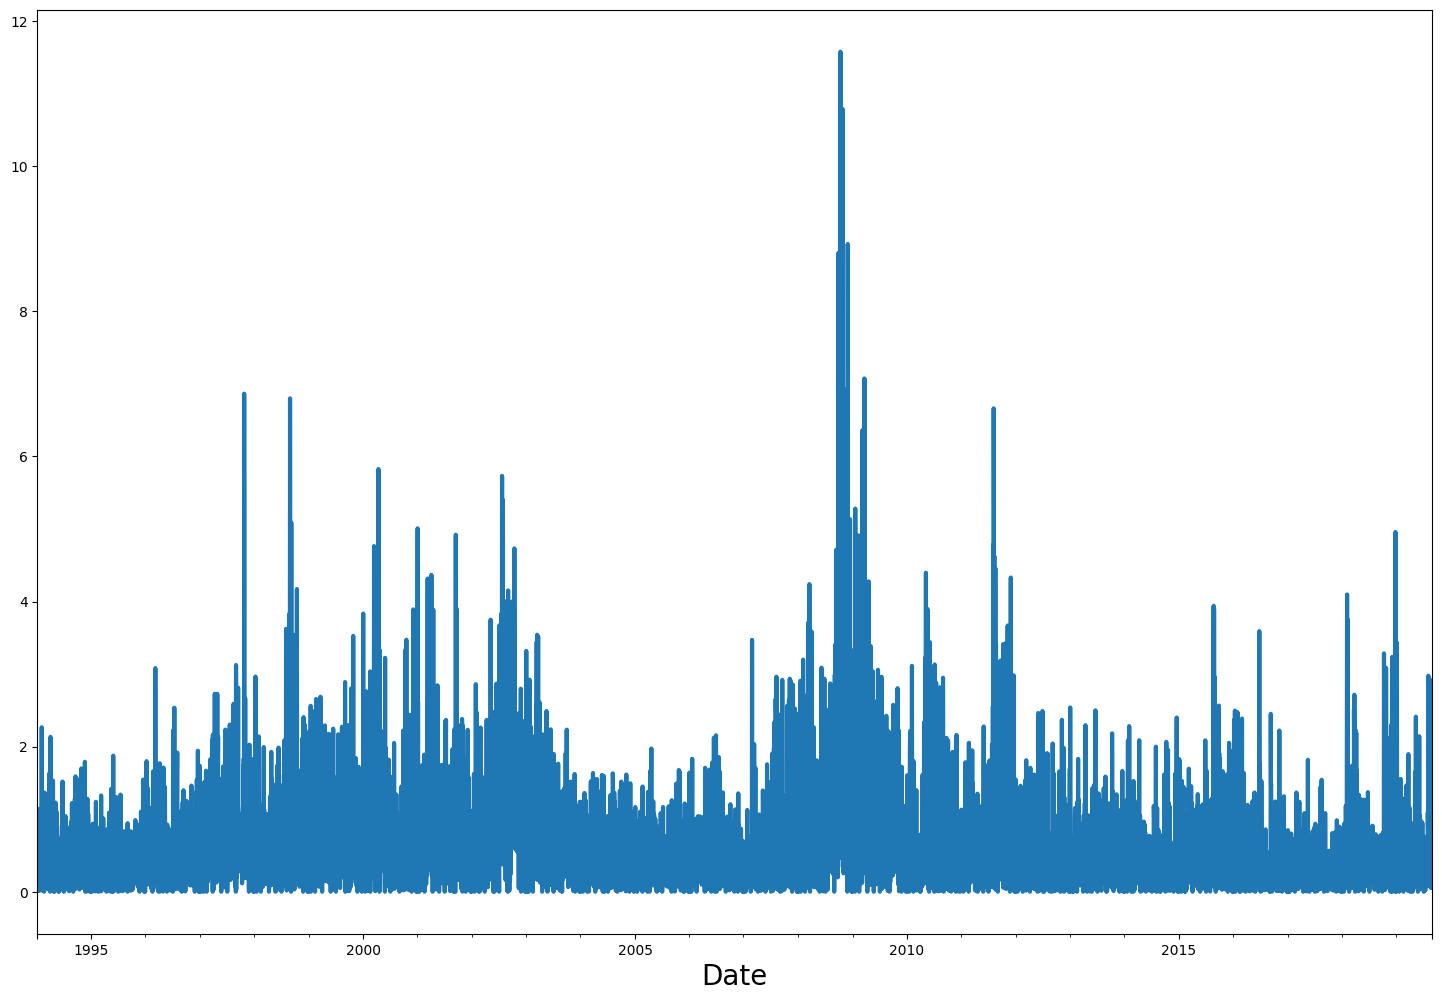

In [ ]:
# Строим график волатильности SPX, которая была вычислена в предыдущем шаге
data["spx_vol"].plot()

# Отображаем график
plt.show()


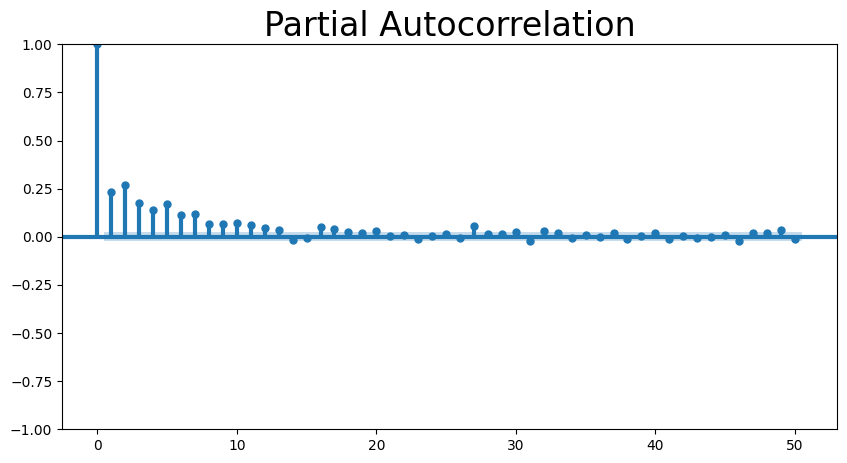

In [ ]:
import statsmodels.graphics.tsaplots as sgt

# Импортируем библиотеку для визуализации PACF
from matplotlib import pyplot as plt

# Разделяем данные на обучающую и тестовую выборки
train_df = data.loc[:"2018-12-31"]
test_df = data.loc["2019-01-01":]

# Настроим размер графика для удобства
plt.rcParams["figure.figsize"] = 10, 5

# Строим график PACF (Partial Autocorrelation Function) для волатильности SPX
# train_df.spx_vol[1:] исключает первое значение, так как PACF требует данных, начиная с второго значения
sgt.plot_pacf(train_df.spx_vol[1:], lags=50, method="ywm")

# Отображаем график
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Применяем тест Дики-Фуллера для проверки стационарности ряда волатильности SPX
adfuller(train_df.spx_vol[1:])


(-6.39534922529237,
 2.0573554561901765e-08,
 32,
 6484,
 {'1%': -3.4313589282423522,
  '5%': -2.8619858596459524,
  '10%': -2.567007327763762},
 14596.425117785417)

Глядя на графики PACF для доходности и волатильности, становится ясно, что самый значтельный - 2 лаг, а затем уровни значимости значительно падают. Итак, мы построим модель GARCH(2, 2).

In [ ]:
# нам важно сохранить объем датасета, поэтому берем за исходные данные весь датасет с индексами, который содержит
# и train и test часть
garch_df = pd.DataFrame(data["spx_vol"].loc[data.index])

# далее необходимо использовать актуальные обучающие данные, которые находятся в выборке train_df.
# Мы никак не преобразовывали нашу обучающую выборку, поэтому фактически, train_df совпадает с данными в data,
# Но если вы применяете к вашей обечающей выборке какие либо преобразования, например скользящее среднее
# для сглаживания, то необходимо передать измененный train_df датасет.

garch_df.loc[train_df.index, "spx_vol"] = train_df["spx_vol"].dropna()

In [ ]:
garch_df

,spx_vol
Date,
1994-01-06,NaN
1994-01-07,0.595136
1994-01-10,1.142795
1994-01-11,0.239860
1994-01-12,0.008438
...,...
2019-08-26,1.098299
2019-08-27,0.320318
2019-08-28,0.654548


In [ ]:
!pip install -q arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.1/985.1 kB 8.6 MB/s eta 0:00:00


In [ ]:
# Импортируем модель ARCH из библиотеки arch
from arch import arch_model

# Создаем модель GARCH(2,2) для анализа волатильности SPX, используя данные train_df
model = arch_model(garch_df["spx_vol"].dropna(), p=2, q=2)

# Обучаем модель, используя данные до первого объекта из тестовой выборки (last_obs=test_df.index[0])
# update_freq=5 указывает, что обновления параметров модели будут производиться каждые 5 шагов
model_results = model.fit(last_obs=test_df.index[0], update_freq=5)

# Выводим результаты модели
model_results.summary()


Iteration:      5,   Func. Count:     50,   Neg. LLF: 7099.575053673434
Iteration:     10,   Func. Count:     90,   Neg. LLF: 6534.059785845555
Iteration:     15,   Func. Count:    128,   Neg. LLF: 6509.361020332575
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6509.361009200937
            Iterations: 17
            Function evaluations: 141
            Gradient evaluations: 17


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                spx_vol   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6509.36
Distribution:                  Normal   AIC:                           13030.7
Method:            Maximum Likelihood   BIC:                           13071.4
                                        No. Observations:                 6517
Date:                Sat, Nov 09 2024   Df Residuals:                     6516
Time:                        21:11:07   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.5505  1.077e-02     51.120      0.000 [  0.529,  0.572]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0137  3.619e-03      3.773  1.611e-04 [6.563e-03,2.075e-02]
alpha[1]       0.0704  1.850e-02      3.803  1.428e-04   [3.410e-02,  0.107]
alpha[2]       0.1162  2.731e-02      4.256  2.079e-05   [6.271e-02,  0.170]
beta[1]        0.1568  8.870e-02      1.768  7.710e-02  [-1.705e-02,  0.331]
beta[2]        0.6444  8.451e-02      7.625  2.432e-14     [  0.479,  0.810]
============================================================================

Covariance estimator: robust
"""

In [ ]:
# Создаем копию тестовой выборки, чтобы сохранить структуру данных
predictions_df = test_df.copy()

# Добавляем в DataFrame новый столбец "Predictions", который будет содержать прогнозируемую дисперсию остатков модели
# Для этого мы используем метод forecast() модели GARCH, который возвращает прогнозы на будущее,
# а затем выбираем столбец residual_variance (прогнозируемая дисперсия остатков) для индексов, соответствующих test_df.
predictions_df["Predictions"] = model_results.forecast().residual_variance.loc[
    test_df.index
]


Мы получаем предсказания с помощью `model_results.forecast()`.

Любое обращение к методу `forecast()` возвращает объект `ARCHModelForecast` с тремя основными атрибутами:

* `.mean` — условное среднее значение ряда;
* `.variance` — условная дисперсия прогноза;
* `.residual_variance` — прогнозируемая условная дисперсия остатков. `Residual_variance` будет отличаться от `variance` в случаях, когда значения ряда (не дисперсии, а именно сами значения) имеют зависимость от себя в прошлом. Для предсказания дисперсии мы используем `residual_variance`, так как в нашем случае ряд стационарен и `residual_variance` и `variance` возвращают одинаковые значения.

Обратите внимание, что при инициализации модели подаётся вся выборка `model = arch_model(garch_df["spx_vol"].dropna(), p=2, q=2)`. Модель не может предсказать волатильность на основе прошлых значений процентных изменений, не имея тестовой выборки. Если в такую модель подать только выборку `train`, метод `forecast()` выдаст ошибку именно из-за отсутствия тестовой выборки.

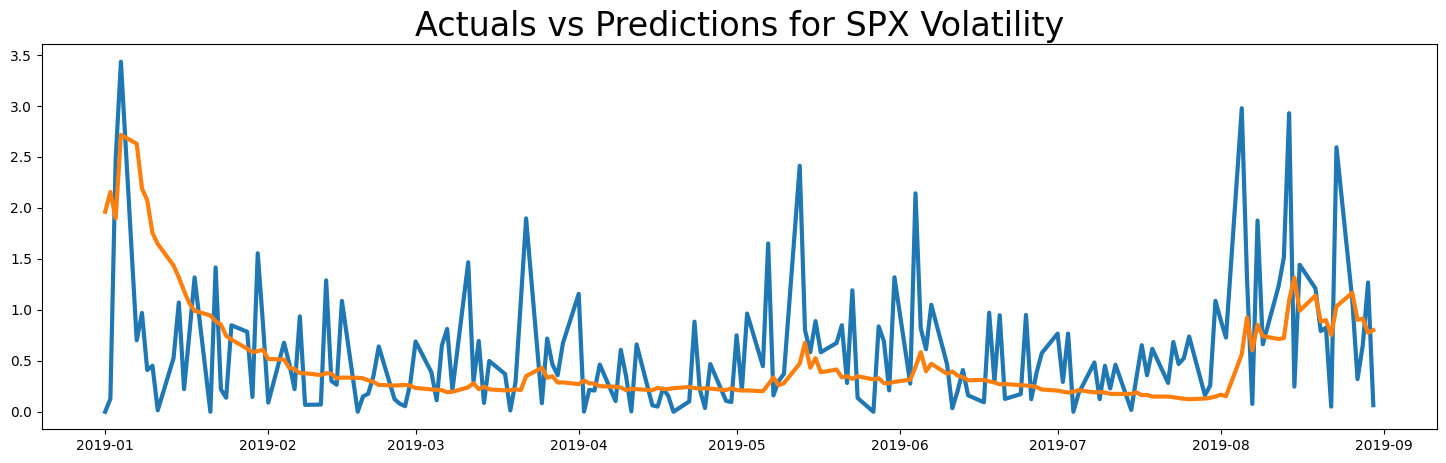

In [ ]:
from matplotlib import pyplot as plt

# Устанавливаем размер графика
plt.rcParams["figure.figsize"] = 18, 5

# Строим график для фактической волатильности (absolut значения из predictions_df["spx_vol"]) и предсказанной волатильности (predictions_df["Predictions"])
plt.plot(predictions_df["spx_vol"].abs(), label="Actual SPX Volatility")
plt.plot(predictions_df["Predictions"], label="Predicted SPX Volatility")

# Добавляем заголовок графика и устанавливаем размер шрифта
plt.title("Actuals vs Predictions for SPX Volatility", size=24)

# Отображаем график
plt.show()


In [ ]:
# Импортируем необходимые библиотеки: numpy и mean_squared_error из sklearn.metrics
import numpy as np
from sklearn.metrics import mean_squared_error

# Вычисляем среднеквадратичную ошибку (MSE) между фактическими значениями волатильности (abs) и предсказанными значениями
mse = mean_squared_error(
    predictions_df["spx_vol"].abs(), predictions_df["Predictions"]
)

mse



0.4209119121422687

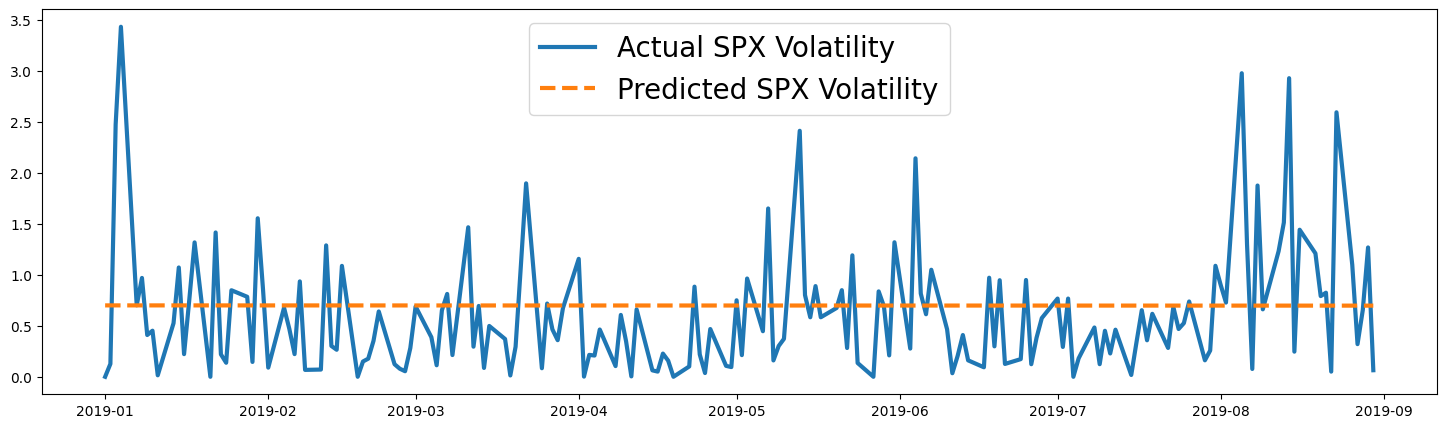

In [ ]:
# Импортируем линейную регрессию из библиотеки sklearn
from sklearn.linear_model import LinearRegression

# Создаем входные данные для обучения (X_train) и тестирования (X_test)
# В качестве признаков используем просто индексы (номера строк) из исходного DataFrame
X_train = pd.DataFrame(range(data["spx_vol"].shape[0]))[: train_df.shape[0]].fillna(0)
X_test = pd.DataFrame(range(data["spx_vol"].shape[0]))[train_df.shape[0] :].fillna(0)

# Целевая переменная для обучения и тестирования - волатильность
y_train = train_df["spx_vol"].fillna(0)
y_test = test_df["spx_vol"].fillna(0)

# Создаем объект модели линейной регрессии и обучаем модель
lr = LinearRegression()
lr.fit(X_train, y_train)

# Предсказываем значения для тестового набора
lr_predict = lr.predict(X_test)

# Строим график с фактическими и предсказанными значениями
plt.plot(y_test, label="Actual SPX Volatility")
plt.plot(pd.Series(lr_predict, index=y_test.index), label="Predicted SPX Volatility", linestyle="--")

# Отображаем легенду и показываем график
plt.legend()
plt.show()


Визуально видно, что линейная регрессия в чистом виде не справляется. Возможно, стоит добавить параметры от даты, такие как: день недели, число, месяц, год, и может быть тогда результаты линейной модели будут лучше, но пока GARCH справилась лучше с предсказанием дисперсии.

## Другие методы предсказания временных рядов

Мы рассмотрели наиболее распространённые статистические методы, которые используются уже много лет. Эти инструменты являются теоретической базой, и о них часто спрашивают на собеседованиях. Однако анализ временных рядов не ограничен этими инструментами.

Список открывает популярная модель с говорящим названием «Пророк» от Facebook*.

### Prophet

> **Prophet** — это метод прогнозирования данных временных рядов на основе AR-модели, в которой учтены годовая, еженедельная и ежедневная сезонности, а также эффекты праздничных дней.

*Prophet* лучше всего работает с временными рядами, которые имеют сильные сезонные эффекты, а данные накоплены за несколько сезонов. Алгоритм устойчив к отсутствующим данным и сдвигам в тренде и обычно хорошо справляется с выбросами.

***Prophet*** — библиотека с открытым исходным кодом, выпущенная командой Facebook Core Data Science. Для загрузки метод также доступен в PyPI (через `pip install`).

Prophet следует API модели sklearn. Это значит, что мы можем пользоваться им и его методами так же, как и в случае с моделями из sklearn: для инициализации модели создаётся экземпляр класса Prophet (`myModel = Prophet()`), а затем вызываются его методы обучения (`.fit()`) и прогнозирования (`.predict()`). Входные данные для методов Prophet должны представлять собой датафрейм с двумя столбцами — DS и Y.

* Столбец DS (отметка даты) должен иметь временной формат (`DateTime`), например ГГГГ-ММ-ДД — для даты или ГГГГ-ММ-ДД ЧЧ:ММ:СС — для отметки времени.

* Столбец Y должен быть числовым и представлять измерение, которое мы хотим спрогнозировать.

В качестве примера давайте рассмотрим временной ряд ежедневных просмотров страницы футболиста Пейтона Мэннинга на Wikipedia.

Импортируем *Prophet* и другие необходимые библиотеки, а также считаем датасет.

In [ ]:
# Импортируем необходимые библиотеки: pandas для работы с данными и Prophet для моделирования временных рядов
from prophet import Prophet

# Загружаем данные с указанного URL и считываем их в DataFrame
url = 'https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv'
df = pd.read_csv(url)

# Выводим первые 5 строк загруженного DataFrame для просмотра данных
df.head()


,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572


Обучим модель на датасете:

In [ ]:
model = Prophet()
model.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpty9cqs8u/trvkdhcs.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpty9cqs8u/suf0pv5j.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=34846', 'data', 'file=/tmp/tmpty9cqs8u/trvkdhcs.json', 'init=/tmp/tmpty9cqs8u/suf0pv5j.json', 'output', 'file=/tmp/tmpty9cqs8u/prophet_modelgb93tryn/prophet_model-20241109212026.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:20:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:20:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Для получения прогноза необходимо использовать DataFrame со столбцом DS, содержащим даты, для которых должен быть сделан прогноз. Вы можете получить такой DataFrame, используя вспомогательный метод `Prophet.make_future_dataframe()`, в который необходимо передать число дней для совершения прогноза. По умолчанию он также будет включать более ранние даты, поэтому мы также увидим, как обучалась модель.

In [ ]:
# Используем модель Prophet для создания DataFrame для прогнозирования на будущее.
# Метод make_future_dataframe создаст новые строки для дополнительных 365 дней.
future_df = model.make_future_dataframe(periods=365)

# Выводим последние строки DataFrame future_df, чтобы проверить, как выглядят добавленные даты.
future_df.tail()


,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


В результате построения прогноза каждому DS будет присвоено прогнозируемое значение (YHAT). Также в прогнозном датафрейме будут два новых столбца (`'yhat_lower'`, `'yhat_upper'`), в которых будут находиться верхняя и нижняя границы доверительного интервала:

In [ ]:
# Прогнозируем значения с помощью модели Prophet для будущих дат
forecast_df = model.predict(future_df)

# Выводим последние строки прогноза, включая прогнозируемые значения (yhat),
# а также нижнюю и верхнюю границы прогнозируемого интервала (yhat_lower, yhat_upper)
forecast_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()


,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.210097,7.460029,8.947921
3266,2017-01-16,8.535122,7.786391,9.245976
3267,2017-01-17,8.322549,7.601525,9.076094
3268,2017-01-18,8.155179,7.464802,8.903296
3269,2017-01-19,8.167136,7.440492,8.939401


Мы можем отобразить прогноз, вызвав метод `Prophet.plot` и передав ему полученный датафрейм с результатами прогноза:

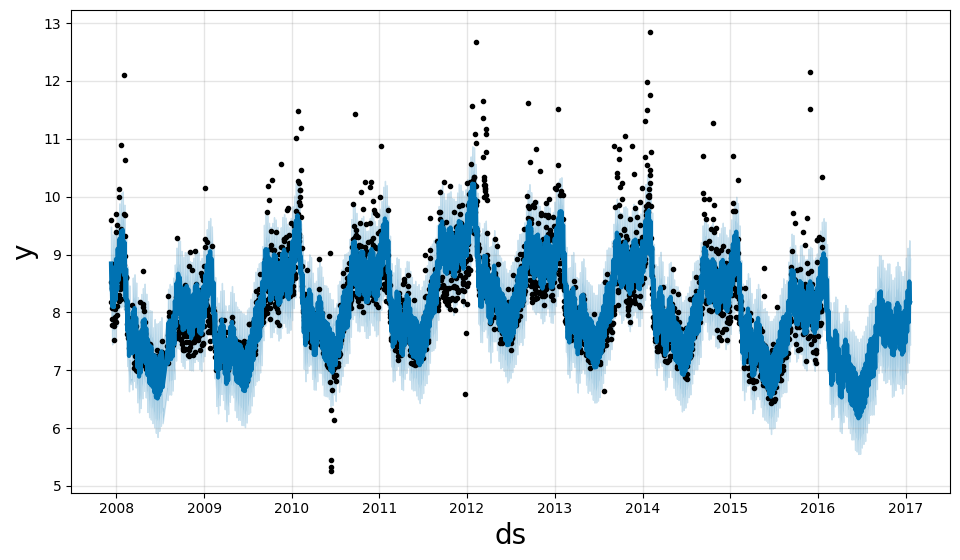

In [ ]:
# Строим график прогноза с помощью метода plot модели Prophet
fig = model.plot(forecast_df)


Чтобы увидеть компоненты ряда, можно использовать метод `Prophet.plot_components`. По умолчанию предоставляются тренд и годовая и недельная сезонность временного ряда.

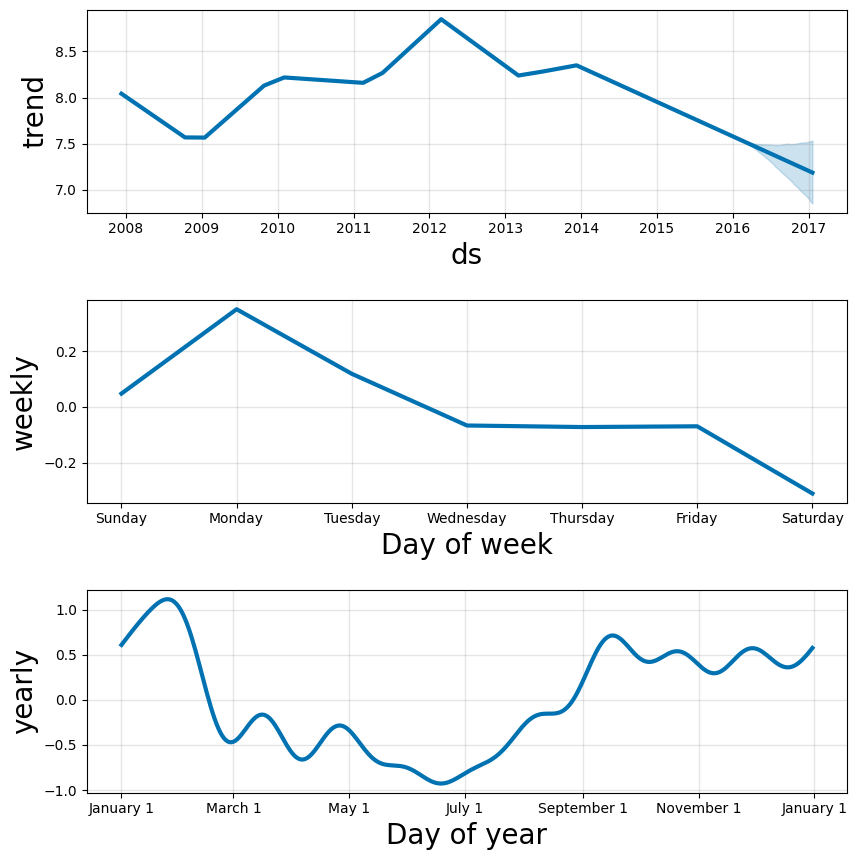

In [ ]:
fig = model.plot_components(forecast_df)

### NeuralProphet

> **NeuralProphet** — основанная на PyTorch усовершенствованная и более сложная модель, которая комбинирует в себе преимущества традиционных моделей для анализа временных рядов и методов глубокого обучения. NeuralProphet можно установить с помощью pip (`pip install neuralprophet`).

### Модели классического ML

Можно использовать другие модели машинного обучения:

* другие линейные модели регрессии (логистическая, ридж- и лассо-регрессия);

* ансамбли деревьев (случайный лес, градиентный бустинг над деревьями);

* SVM (метод опорных векторов);

* KNN (метод ближайших соседей);

* и др.

Чтобы улучшить результаты такого подхода, стоит уделить особое внимание feature engineering (добавлению признаков).

**Основные подходы к генерации признаков**:

1. На временной ряд могут влиять **внешние факторы**. Так, например, в задаче предсказания числа посетителей кинотеатра могут быть важные второстепенные факторы, такие как наличие или отсутствия дождя и температура воздуха, а в задаче прогнозирования объёма заказов косметики — наличие или отсутствие рекламы этого товара в недавнее время. Всё это можно добавлять в качестве дополнительных признаков.

2. Также хорошей практикой является добавление в качестве признаков **лагов**. Это сдвиг временного ряда во времени. Тут стоит избегать так называемых «ликов» (от англ. leak — утечка) — попаданий ответов в тестовую выборку. Так, если вам нужно сделать прогноз на семь дней вперёд, то в качестве признаков вы не можете использовать лаги с 1 по 7 (Для последнего дня из тестовой выборки будут неизвестны значения предыдущих шести дней, так как для них нам тоже нужно сделать предсказания), а вот взятие лагов больше размера тестовой выборки — хорошая практика. То есть если размер вашей тестовой выборки — семь дней, то лаги стоит брать, начиная с 8 и более.

3. Используя специальные методы, некоторое количество признаков для временных рядов можно получить от **даты**:

 * час/минута/секунда,
 * число,
 * месяц,
 * год,
 * день недели,
 * день в году,
 * квартал,
 * выходной или рабочий день,
 * праздничный или рабочий день,
 * другие признаки.

Часто добавление этих признаков даёт хороший прирост качества модели.

Несомненно, значимость таких признаков зависит от задачи, но совершенно точно временные ряды, напрямую связанные с человеческой деятельностью, зависимы от времени. Для добавления признаков от даты удобнее всего пользоваться встроенными методами `Series.dt`. Для этого сначала необходимо привести столбец к типу `Datetime`, а затем вызвать интересующий вас метод.